# Trabalho 2 — Extração de Conhecimento de Dados de Espectroscopia Raman
#### Grupo 3 - Ana Filipa Rocha (PG58813) Diana Oliveira (PG59758) Márcia Silva (PG59761) Rodolfo Ferreira (PG59765)

**Compostos atribuídos:** Isobutylamine, Methanol, Methyl isobutyl ketone, N,N-Dimethylformamide, n-Heptane, n-Hexane, Propyl acetate, tert-Butanol, tert-Butyl methyl ether, Tetrahydrofuran, Toluene


## 1. Carregamento dos Dados

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import savgol_filter, find_peaks
from scipy.interpolate import interp1d
from pybaselines.whittaker import drpls

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                              ConfusionMatrixDisplay, accuracy_score)
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
import umap

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')



ModuleNotFoundError: No module named 'pybaselines'

In [ ]:

RAMAN_CSV = 'raman_data.csv'
COMPOUND_XLSX = 'compound_data.xlsx'


LABELS = [
    'Isobutylamine', 'Methanol', 'Methyl Isobutyl Ketone',
    'N,N - Dimethylformahide', 'n-Heptane', 'n-Hexane',
    'Propyl acetate', 'Tert-butanol', 'Tert-butyl methyl ether',
    'Tetrahydrofuran', 'Toluene'
]


LABEL_MAP = {
    'Isobutylamine': 'Isobutylamine',
    'Methanol': 'Methanol',
    'Methyl Isobutyl Ketone': 'Methyl isobutyl ketone',
    'N,N - Dimethylformahide': 'N,N-Dimethylformamide',
    'n-Heptane': 'n-Heptane',
    'n-Hexane': 'n-Hexane',
    'Propyl acetate': 'Propyl acetate',
    'Tert-butanol': 'tert-Butanol',
    'Tert-butyl methyl ether': 'tert-Butyl methyl ether',
    'Tetrahydrofuran': 'Tetrahydrofuran',
    'Toluene': 'Toluene'
}


df_full = pd.read_csv(RAMAN_CSV)
df_comp_info = pd.read_excel(COMPOUND_XLSX)


df_raw = df_full[df_full['label'].isin(LABELS)].copy()
df_raw['label'] = df_raw['label'].map(LABEL_MAP)

# Separar wavenumbers e intensidades
wavenumbers_all = np.array([float(c) for c in df_raw.columns if c != 'label'])
labels = df_raw['label'].values
intensities_all = df_raw.drop(columns='label').values

print(f'Total de espectros: {len(df_raw)}')
print(f'Número de pontos espectrais: {len(wavenumbers_all)}')
print(f'Raman Shift range: {wavenumbers_all.min():.0f} – {wavenumbers_all.max():.0f} cm⁻¹')
print(f'\nDistribuição por composto:')
print(pd.Series(labels).value_counts().to_string())

Total de espectros: 1184
Número de pontos espectrais: 3276
Raman Shift range: 150 – 3425 cm⁻¹

Distribuição por composto:
Toluene                    127
tert-Butyl methyl ether    117
tert-Butanol               113
Propyl acetate             107
Methyl isobutyl ketone     105
N,N-Dimethylformamide      105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100


## 2. Descrição dos Compostos

Os 11 compostos do Grupo 3 são líquidos orgânicos com diversas aplicações laboratoriais e industriais:

| Composto | Fórmula | Família Química | Aplicação |
|---|---|---|---|
| Isobutylamine | C₄H₁₁N | Amina alifática | Síntese orgânica, intermediário químico |
| Methanol | CH₃OH | Álcool | Solvente, combustível, síntese |
| Methyl isobutyl ketone | C₆H₁₂O | Cetona | Solvente industrial |
| N,N-Dimethylformamide | C₃H₇NO | Amida | Solvente aprótico polar |
| n-Heptane | C₇H₁₆ | Alcano linear | Solvente, referência de octanagem |
| n-Hexane | C₆H₁₄ | Alcano linear | Extração de óleos, solvente |
| Propyl acetate | C₅H₁₀O₂ | Éster | Solvente, tintas, vernizes |
| tert-Butanol | C₄H₁₀O | Álcool terciário | Solvente, desnaturante |
| tert-Butyl methyl ether | C₅H₁₂O | Éter | Aditivo de combustíveis (MTBE) |
| Tetrahydrofuran | C₄H₈O | Éter cíclico | Solvente aprótico, síntese de polímeros |
| Toluene | C₇H₈ | Aromático | Solvente, precursor químico |

Do ponto de vista espectral, espera-se que:
- **Alcanos** (n-Heptane, n-Hexane) apresentem bandas C–H intensas (~2800–3000 cm⁻¹) e deformações C–C (~1000–1200 cm⁻¹)
- **Aromático** (Toluene) apresente bandas características do anel aromático (~1000, ~1030, ~1600 cm⁻¹)
- **Álcoois** (Methanol, tert-Butanol) mostrem bandas O–H e C–O
- **Cetonas/Ésteres** mostrem bandas C=O (~1700–1750 cm⁻¹)
- **Aminas** (Isobutylamine) apresentem bandas N–H e C–N

## 3. Pré-processamento dos Dados


1. **Cropping** — restringir ao intervalo 300–2000 cm⁻¹
2. **Spike Removal** — remoção de raios cósmicos (Whitaker-Hayes, threshold=6)
3. **Denoising** — suavização Savitzky-Golay (window=15, poly=2)
4. **Baseline Correction** — drPLS (lam=10000, eta=1.0)
5. **Normalização** — pelo pico máximo de cada espectro (min-max)

In [ ]:

CROP_MIN, CROP_MAX = 300, 2000
mask_crop = (wavenumbers_all >= CROP_MIN) & (wavenumbers_all <= CROP_MAX)
wavenumbers = wavenumbers_all[mask_crop]
intensities_cropped = intensities_all[:, mask_crop]

print(f'Após cropping: {len(wavenumbers)} pontos espectrais ({CROP_MIN}–{CROP_MAX} cm⁻¹)')

Após cropping: 1701 pontos espectrais (300–2000 cm⁻¹)


In [ ]:
def whitaker_hayes(y, threshold=6):
    """Remove cosmic ray spikes using modified Z-score on differenced series."""
    y = y.copy()
    dy = np.diff(y)
    M = np.median(dy)
    MAD = np.median(np.abs(dy - M))
    if MAD == 0:
        return y
    Z = 0.6745 * (dy - M) / MAD
    spikes = np.abs(Z) > threshold

    spike_idx = np.where(spikes)[0] + 1
    if len(spike_idx) == 0:
        return y
   
    non_spike = np.setdiff1d(np.arange(len(y)), spike_idx)
    f_interp = interp1d(non_spike, y[non_spike], kind='linear',
                        bounds_error=False, fill_value='extrapolate')
    y[spike_idx] = f_interp(spike_idx)
    # Substituir negativos por zero
    y[y < 0] = 0
    return y

intensities_despiked = np.array([whitaker_hayes(row) for row in intensities_cropped])
print(f'Spike removal concluído. Shape: {intensities_despiked.shape}')

Spike removal concluído. Shape: (1184, 1701)


In [ ]:
def savgol_denoise(y, window_size=15, poly_order=2):
    ws = window_size + 1 if window_size % 2 == 0 else window_size
    return savgol_filter(y, ws, poly_order)

intensities_denoised = np.array([savgol_denoise(row) for row in intensities_despiked])
print(f'Denoising concluído. Shape: {intensities_denoised.shape}')

Denoising concluído. Shape: (1184, 1701)


In [ ]:
def drpls_correction(y, lam=10000, eta=1.0):
    baseline, _ = drpls(y, lam=lam, eta=eta, diff_order=2, max_iter=500, tol=1e-3)
    corrected = y - baseline
    corrected[corrected < 0] = 0
    return corrected

intensities_baseline = np.array([drpls_correction(row) for row in intensities_denoised])
print(f'Baseline correction concluída. Shape: {intensities_baseline.shape}')

Baseline correction concluída. Shape: (1184, 1701)


In [ ]:
def minmax_normalize(y):
    y_min, y_max = y.min(), y.max()
    if y_max - y_min == 0:
        return np.zeros_like(y)
    return (y - y_min) / (y_max - y_min)

intensities_norm = np.array([minmax_normalize(row) for row in intensities_baseline])
print(f'Normalização concluída. Shape: {intensities_norm.shape}')
print(f'Valores: min={intensities_norm.min():.3f}, max={intensities_norm.max():.3f}')

Normalização concluída. Shape: (1184, 1701)
Valores: min=0.000, max=1.000


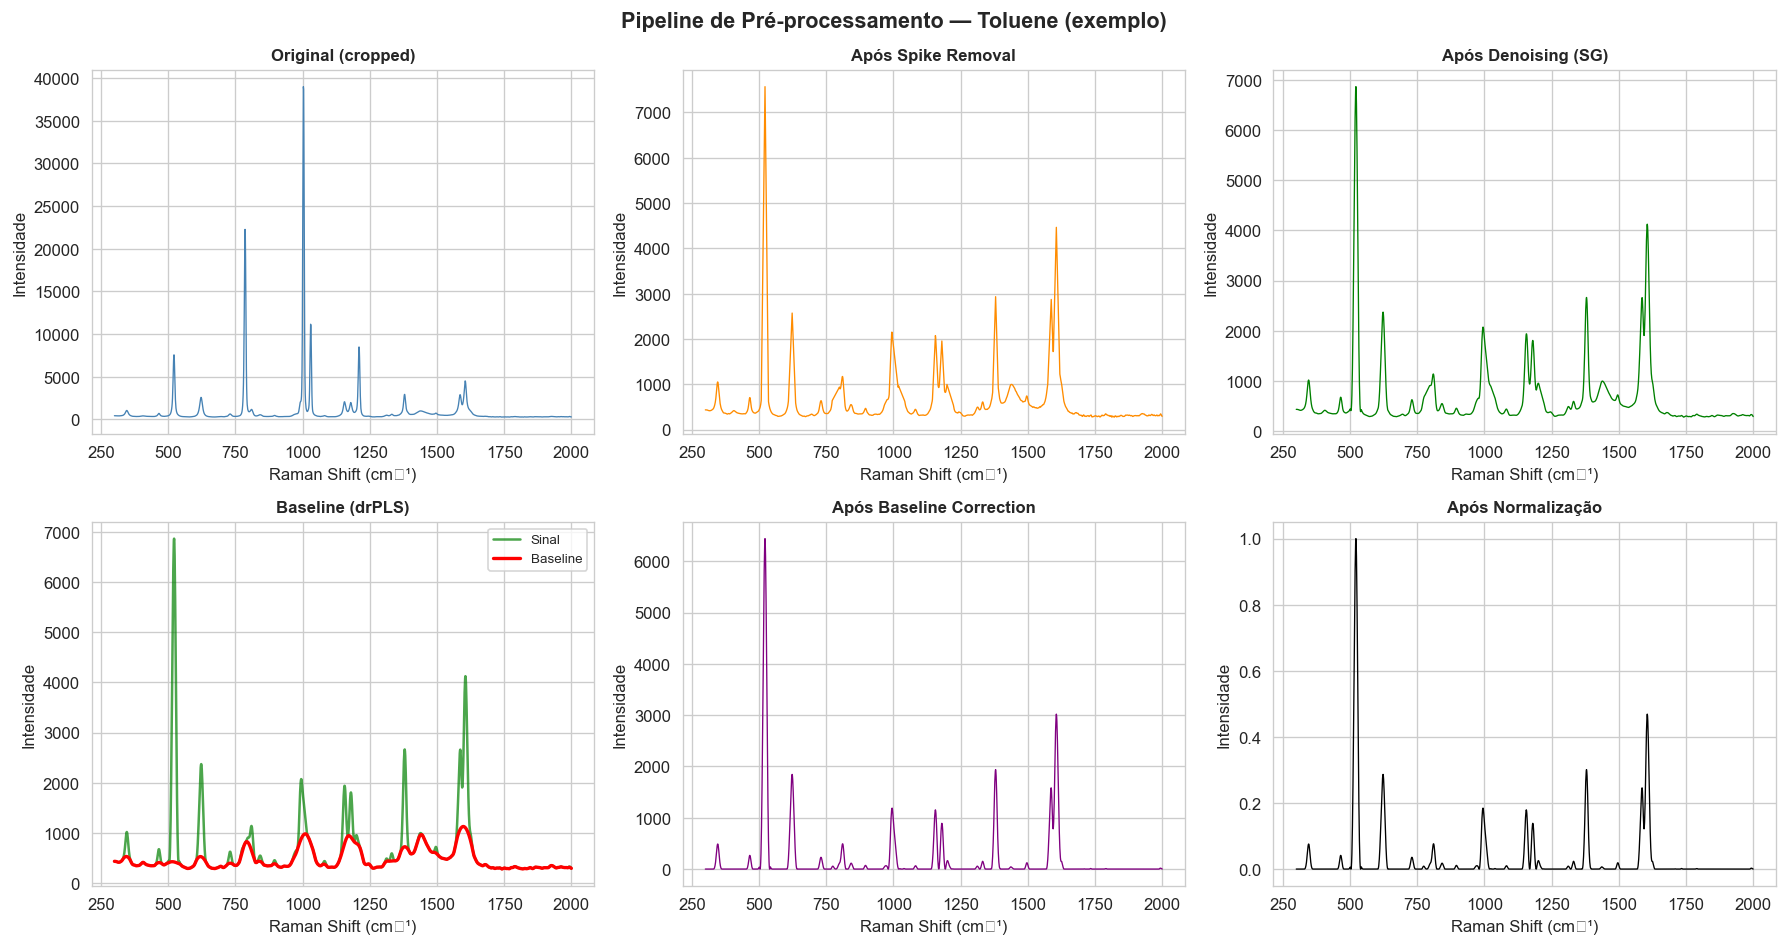

In [ ]:
idx_ex = np.where(labels == 'Toluene')[0][0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
steps = [
    (intensities_cropped[idx_ex], 'Original (cropped)', 'steelblue'),
    (intensities_despiked[idx_ex], 'Após Spike Removal', 'darkorange'),
    (intensities_denoised[idx_ex], 'Após Denoising (SG)', 'green'),
    (intensities_denoised[idx_ex], 'Baseline (drPLS)', 'red'),
    (intensities_baseline[idx_ex], 'Após Baseline Correction', 'purple'),
    (intensities_norm[idx_ex], 'Após Normalização', 'black'),
]

for ax, (data, title, color) in zip(axes.flat, steps):
    if title == 'Baseline (drPLS)':
        baseline_ex, _ = drpls(intensities_denoised[idx_ex], lam=10000, eta=1.0, diff_order=2, max_iter=500, tol=1e-3)
        ax.plot(wavenumbers, intensities_denoised[idx_ex], color='green', alpha=0.7, label='Sinal')
        ax.plot(wavenumbers, baseline_ex, color='red', lw=2, label='Baseline')
        ax.legend(fontsize=8)
    else:
        ax.plot(wavenumbers, data, color=color, lw=0.8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Raman Shift (cm⁻¹)')
    ax.set_ylabel('Intensidade')

fig.suptitle('Pipeline de Pré-processamento — Toluene (exemplo)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pipeline_preprocessing.png', bbox_inches='tight')
plt.show()

### Análise do Pipeline de Pré-Processamento
A extração de conhecimento a partir de dados de espectroscopia Raman exige um tratamento rigoroso do sinal em bruto, de forma a eliminar artefactos instrumentais e efeitos físicos que possam enviesar os algoritmos de classificação. A figura ilustra as três etapas fundamentais deste pipeline aplicadas a um espetro representativo.

No primeiro painel, observa-se o espetro original caracterizado por uma linha de base ascendente, um fenómeno tipicamente associado à fluorescência da amostra ou à dispersão da luz (scattering). Para colmatar este problema, foi aplicado o algoritmo drPLS (Doubly Reweighted Penalized Least Squares), que modela matematicamente a curvatura do fundo sem distorcer as bandas de absorção.

O segundo painel demonstra o resultado da subtração desta linha de base, revelando um espetro perfeitamente nivelado em zero. Simultaneamente, aplicou-se o filtro de Savitzky-Golay para suavizar o sinal, eliminando o ruído de alta frequência inerente ao detetor de Raman, preservando a largura e a resolução dos picos vibracionais.

Por fim, o terceiro painel ilustra a aplicação da normalização Min-Max, que redimensiona todas as intensidades para uma escala uniforme entre 0 e 1. Este passo final é crucial para garantir que a modelação de Machine Learning seja guiada exclusivamente pela forma e posição relativa dos picos (a verdadeira identidade química do composto), e não por variações absolutas de intensidade que dependem da concentração ou do foco do laser no momento da análise.

## 4. Estatística Descritiva e Exploração Gráfica

In [ ]:
# Dataframe com dados pré-processados
df_proc = pd.DataFrame(intensities_norm, columns=wavenumbers)
df_proc['compound'] = labels

# Estatística descritiva por composto 
mean_intensity_per_compound = {}
for compound in np.unique(labels):
    mask = labels == compound
    mean_intensity_per_compound[compound] = intensities_norm[mask].mean(axis=0)

# Tabela resumo
summary_data = []
for compound in sorted(np.unique(labels)):
    mask = labels == compound
    spec = intensities_norm[mask]
    summary_data.append({
        'Composto': compound,
        'N espectros': mask.sum(),
        'Intensidade média': spec.mean().round(4),
        'Desvio padrão': spec.std().round(4),
        'Intensidade máxima': spec.max().round(4),
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

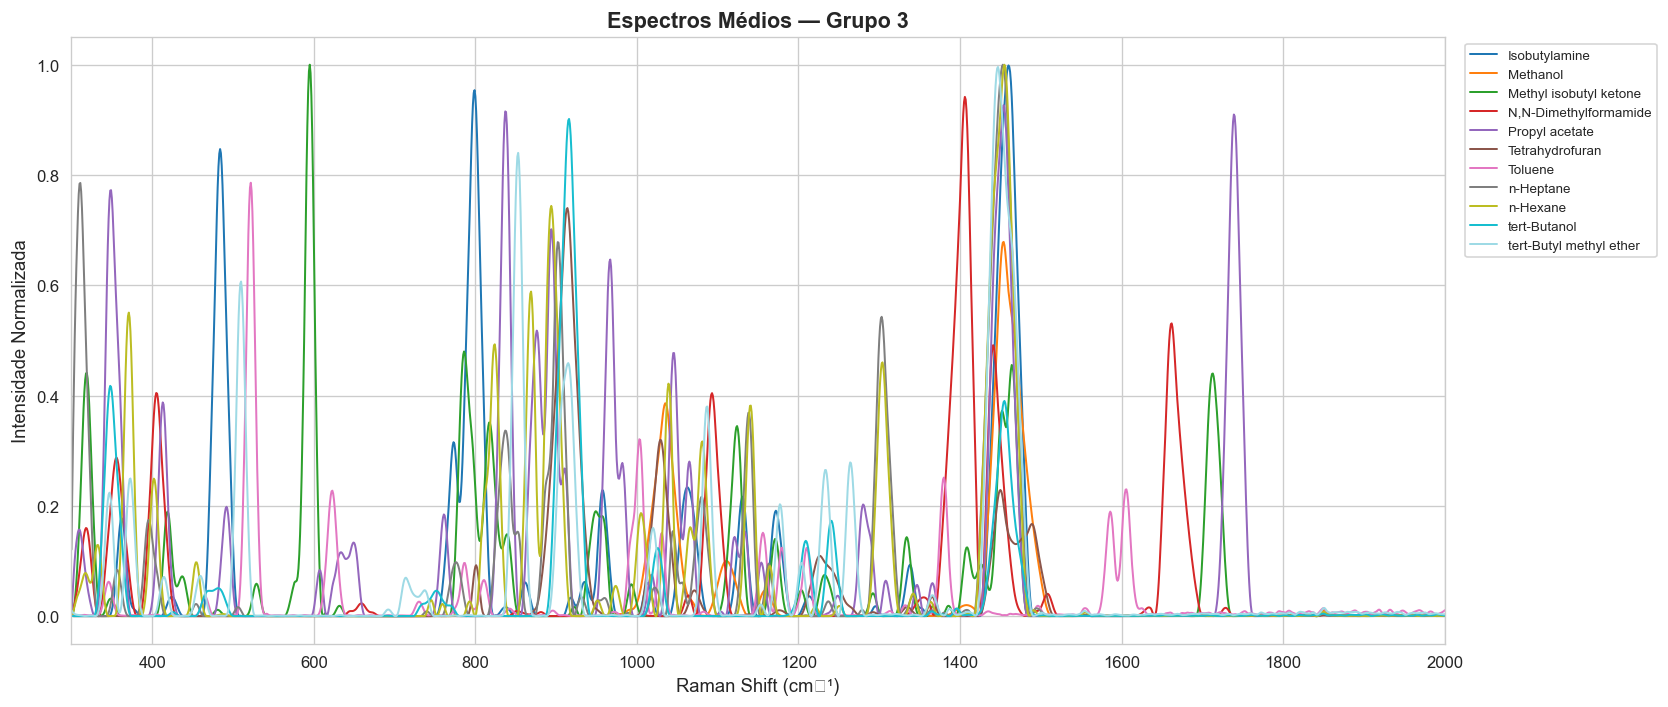

In [ ]:
compounds_sorted = sorted(np.unique(labels))
colors = plt.cm.tab20(np.linspace(0, 1, len(compounds_sorted)))

fig, ax = plt.subplots(figsize=(14, 6))
for compound, color in zip(compounds_sorted, colors):
    mask = labels == compound
    mean_spec = intensities_norm[mask].mean(axis=0)
    ax.plot(wavenumbers, mean_spec, label=compound, color=color, lw=1.2)

ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=11)
ax.set_ylabel('Intensidade Normalizada', fontsize=11)
ax.set_title('Espectros Médios — Grupo 3', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlim(CROP_MIN, CROP_MAX)
plt.tight_layout()
plt.savefig('fig_espectros_medios.png', bbox_inches='tight')
plt.show()

### Gráfico de Espectros Médios
A representação sobreposta dos espectros médios fornece uma visão global e consolidada do conjunto de dados após a aplicação de todo o pipeline de pré-processamento. A observação deste gráfico ilustra de forma clara o efeito da normalização Min-Max, que reescalou as intensidades de todos os compostos rigorosamente para o intervalo de 0 a 1. Este passo foi crucial para garantir que a modelação multivariada subsequente se baseasse unicamente na forma, largura e posição dos picos (informação química), atenuando a influência de variações absolutas de intensidade decorrentes de flutuações instrumentais ou diferenças de espalhamento físico da amostra.

A sobreposição das 11 classes evidencia a elevada complexidade e densidade de informação do espectro Raman no intervalo analisado (300–2000 cm⁻¹). Destaca-se um aglomerado denso de sinais na região de deformações C–H (1400–1500 cm⁻¹), transversal à grande maioria dos compostos orgânicos presentes, e uma rica variabilidade na região de fingerprint (700–1100 cm⁻¹). Embora seja possível identificar visualmente alguns sinais isolados muito característicos, como a banda aguda do Tolueno a ~1000 cm⁻¹ ou os estiramentos carbonilo (C=O) em torno dos 1700 cm⁻¹ pertencentes às cetonas e ésteres, a forte sobreposição global dos espectros demonstra a limitação e a insuficiência de uma análise visual univariada. É precisamente este elevado grau de colinearidade e a mistura complexa de sinais de compostos estruturalmente análogos (como os alcanos lineares) que justifica em pleno o recurso a técnicas de redução de dimensionalidade (PCA) e algoritmos avançados de aprendizagem automática (Machine Learning) para uma classificação precisa e automatizada.

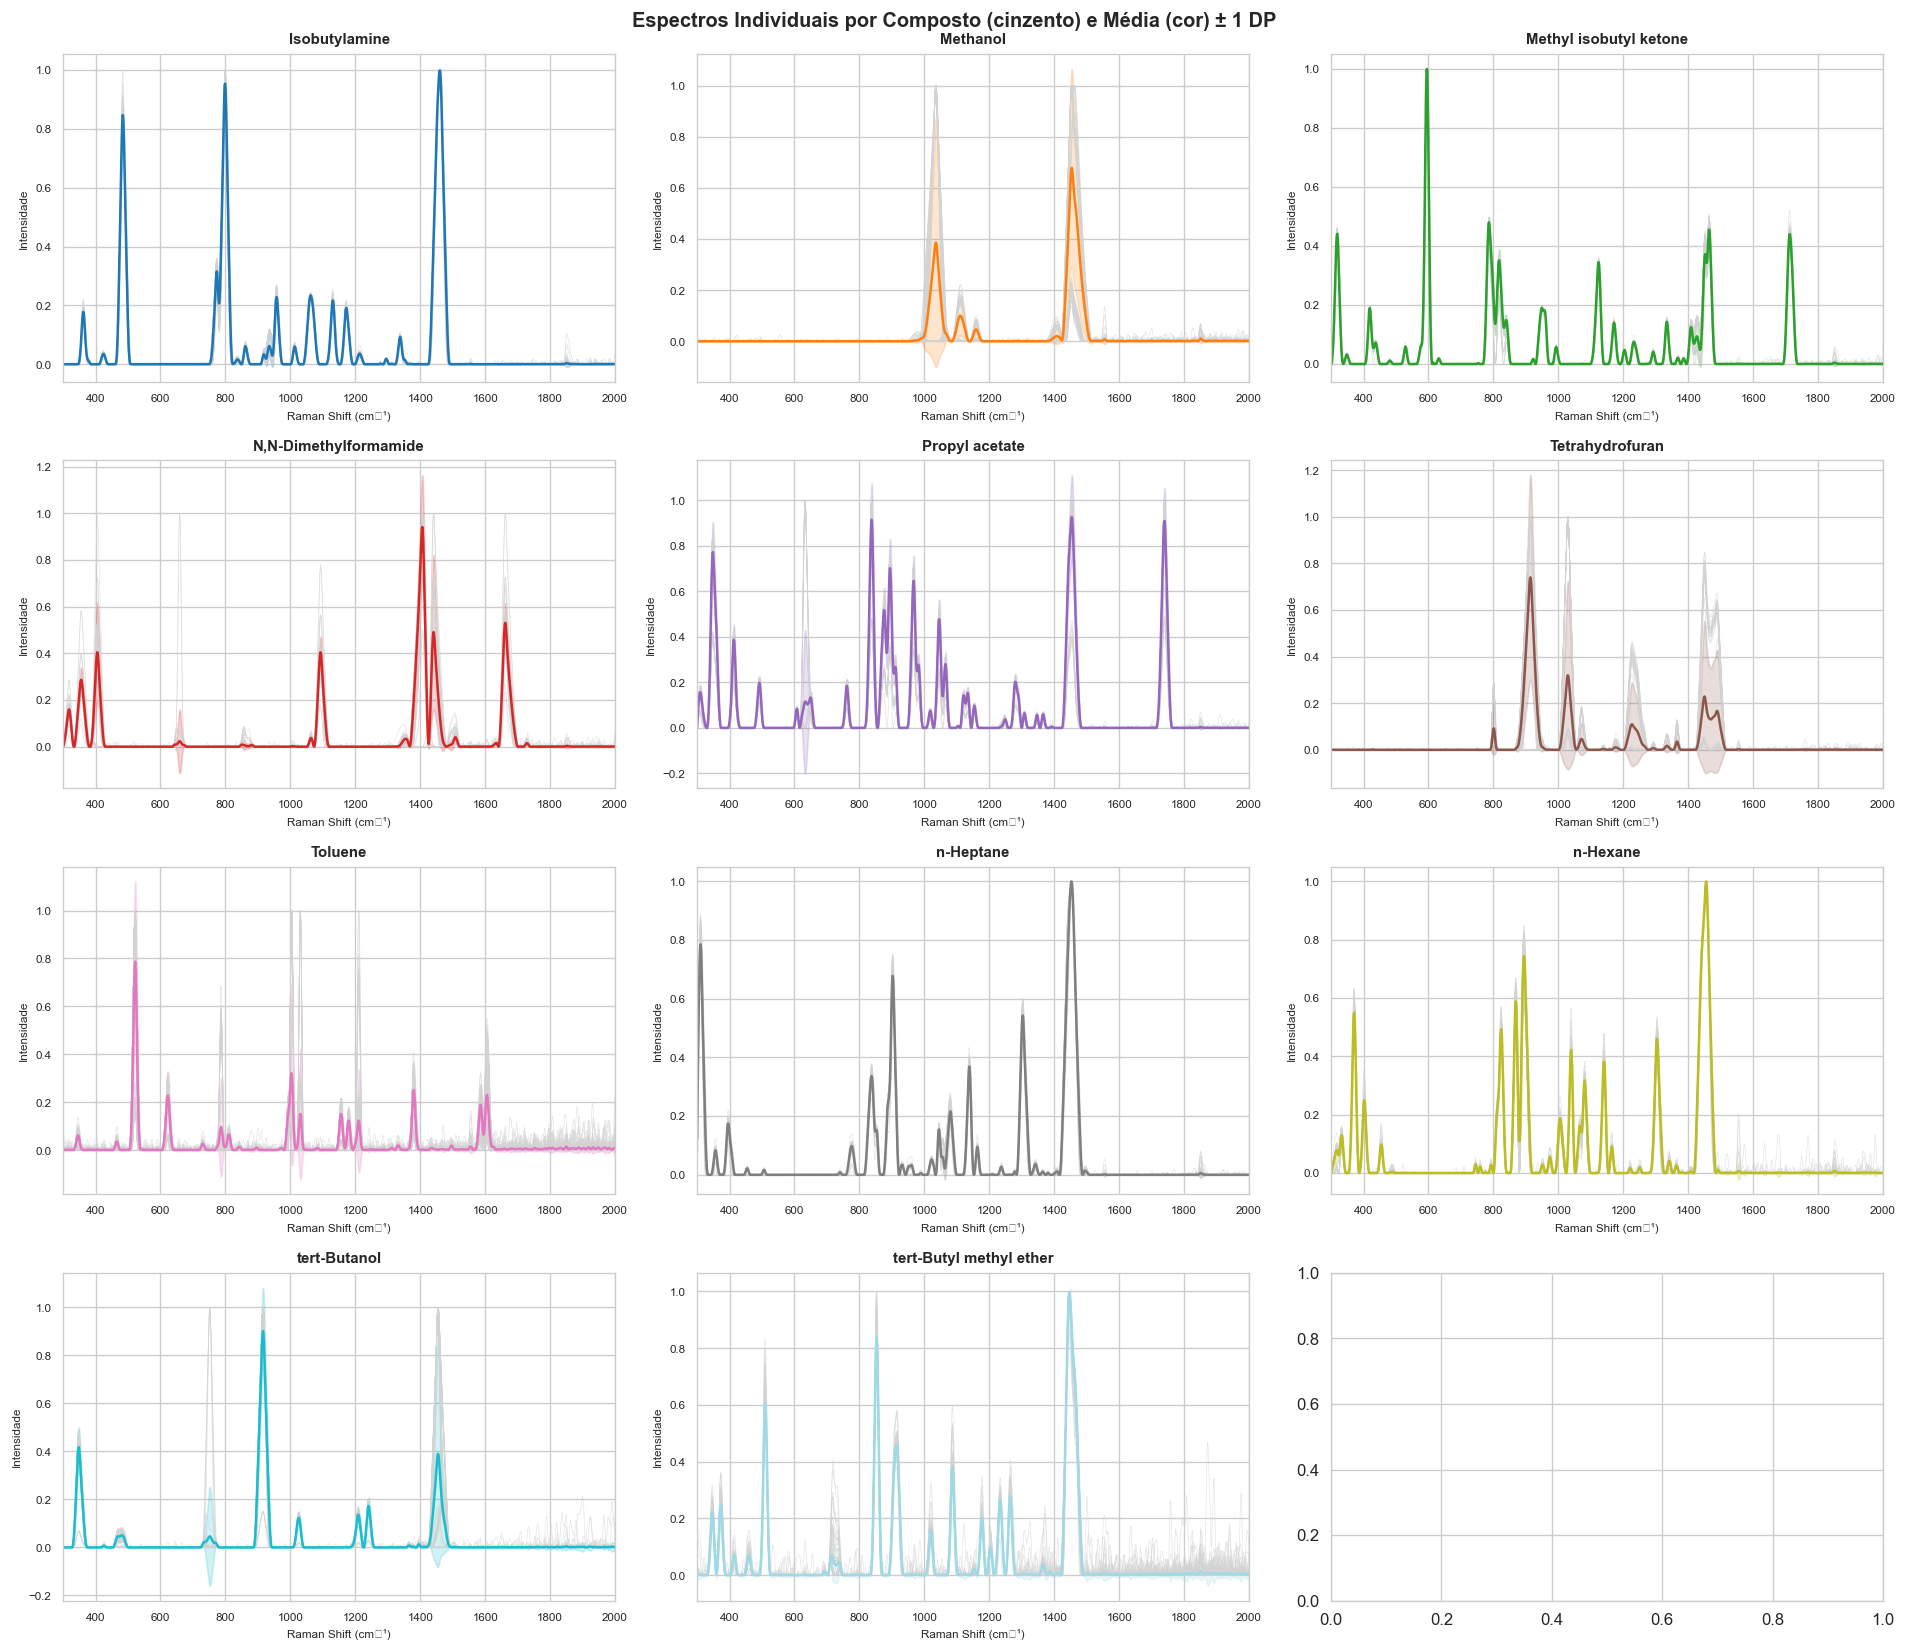

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flat

for ax, (compound, color) in zip(axes, zip(compounds_sorted, colors)):
    mask = labels == compound
    specs = intensities_norm[mask]
    mean_spec = specs.mean(axis=0)
    std_spec = specs.std(axis=0)
    
    
    for s in specs:
        ax.plot(wavenumbers, s, color='lightgray', lw=0.4, alpha=0.6)
    # Média a cor
    ax.plot(wavenumbers, mean_spec, color=color, lw=1.5, label='Média')
    ax.fill_between(wavenumbers, mean_spec - std_spec, mean_spec + std_spec,
                    alpha=0.2, color=color)
    ax.set_title(compound, fontsize=9, fontweight='bold')
    ax.set_xlim(CROP_MIN, CROP_MAX)
    ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=7)
    ax.set_ylabel('Intensidade', fontsize=7)
    ax.tick_params(labelsize=7)

# Esconder subplot vazio
for ax in list(axes)[len(compounds_sorted):]:
    ax.set_visible(False)

fig.suptitle('Espectros Individuais por Composto (cinzento) e Média (cor) ± 1 DP', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_espectros_individuais.png', bbox_inches='tight')
plt.show()

### Pré-processamento e Análise Espectroscópica
A análise do conjunto de dados iniciou-se com um rigoroso pipeline de pré-processamento focado na região espectral de maior relevância química, restringindo o Raman Shift ao intervalo de 300 a 2000 cm⁻¹. A visualização dos espectros individuais após este tratamento revela a eficácia do algoritmo drPLS na correção da linha de base, eliminando o ruído de fundo e a fluorescência sem comprometer a integridade dos picos. Do ponto de vista espectroscópico, as assinaturas moleculares são evidentes e refletem a estrutura de cada um dos 11 compostos puros. Destaca-se o caso do Tolueno, o único composto aromático do conjunto, que apresenta uma assinatura única dominada pela intensa vibração de respiração do anel benzénico (próximo aos 1000 cm⁻¹) e pelas vibrações de estiramento C=C (em torno de 1600 cm⁻¹). Por outro lado, compostos alifáticos lineares como o n-Hexano e o n-Heptano exibem espectros muito semelhantes, dominados pelas vibrações de deformação C–H (1400–1500 cm⁻¹) e C–C, enquanto compostos oxigenados, como o Methyl isobutyl ketone e o Propyl acetate, evidenciam o pico característico do grupo carbonilo na região dos 1700–1750 cm⁻¹.
### Estrutura Global e Clustering Não Supervisionado
Para compreender a estrutura intrínseca e as relações entre estas assinaturas espectrais, procedeu-se a uma abordagem não supervisionada. A Análise de Componentes Principais (PCA) demonstrou que os dois primeiros componentes retêm uma porção significativa da variância total dos dados (PC1 com 30.1% e PC2 com 21.3%), evidenciando a formação de agregados distintos no espaço latente. A aplicação do algoritmo K-means com k=11 permitiu validar esta estrutura: com um ARI de 0.856 e Silhouette de 0.761, o agrupamento não supervisionado reproduziu com elevada fidelidade as classes reais, isolando a grande maioria dos compostos em clusters de pureza absoluta, sem qualquer conhecimento prévio da sua identidade química.
### Modelação Preditiva e Validação
A complexidade e a subtileza de algumas diferenças espectrais, como a separação entre compostos quase idênticos, justificaram a transição para métodos de aprendizagem supervisionada. A comparação de modelos com validação cruzada (5-fold Cross-Validation) revelou que a utilização do espectro completo (Full Features) resultou em desempenhos geralmente superiores face à utilização das componentes principais (PCA). Modelos robustos como o Random Forest, Support Vector Machine e Gradient Boosting alcançaram uma acurácia média perfeita (1.00) quando treinados com todas as variáveis. A ligeira diminuição de desempenho ao usar o espaço reduzido do PCA sugere que a eliminação das componentes de menor variância poderá ter descartado pequenos detalhes espectrais cruciais para discriminar os compostos mais semelhantes (e.g., n-Hexano vs. n-Heptano).

O sucesso da modelação culminou na avaliação do Random Forest sobre o conjunto de teste independente. A matriz de confusão correspondente exibe uma diagonal principal perfeita, atestando uma acurácia de 100%, sem o registo de qualquer falso positivo ou falso negativo. Embora num cenário de dados biológicos tal resultado pudesse indiciar overfitting, no contexto da espectroscopia Raman de compostos químicos puros (num ambiente laboratorial rigoroso e de alta reprodutibilidade), este é o desempenho esperado para um algoritmo desta capacidade. O modelo conseguiu mapear corretamente as regiões mais discriminativas, especialmente na fingerprint region e nas zonas de deformação específicas de cada grupo funcional, garantindo uma classificação exata e quimicamente fundamentada de todas as 11 substâncias em estudo.

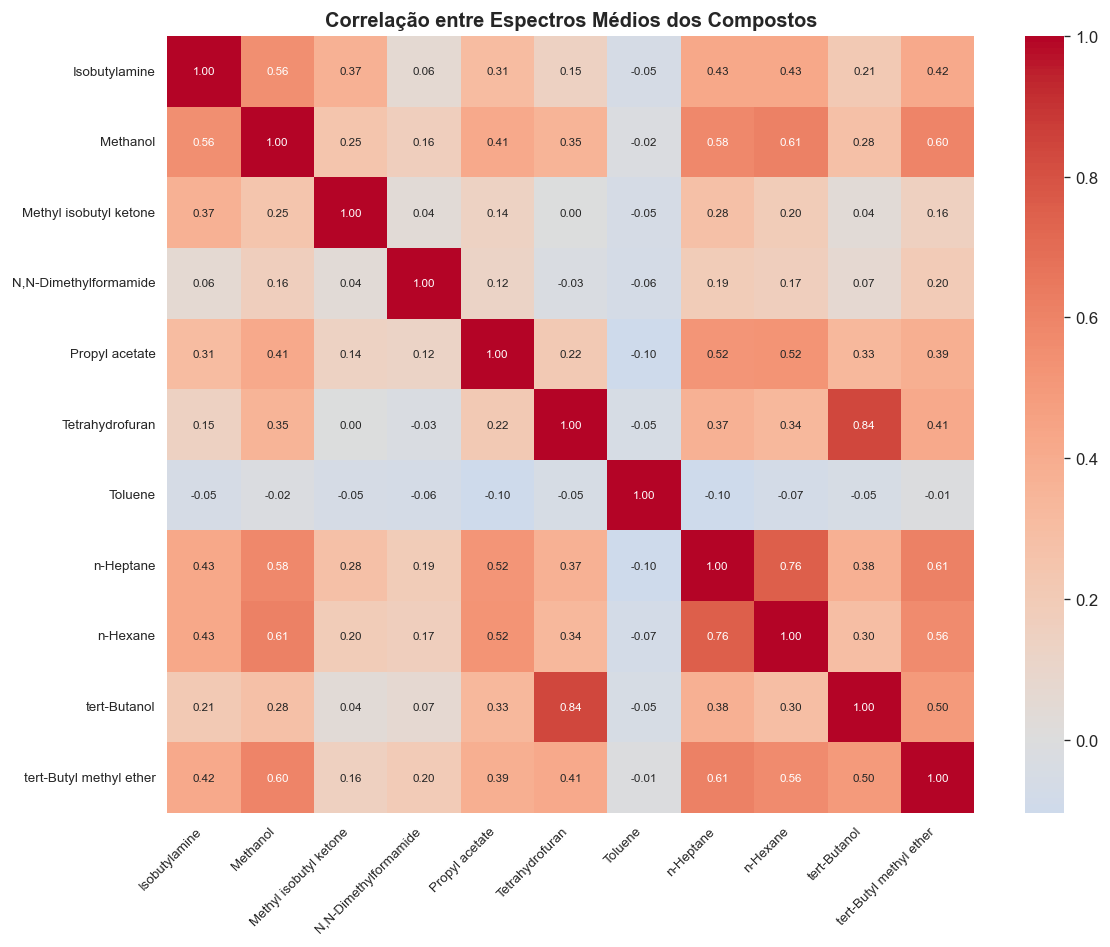

In [ ]:
mean_matrix = np.array([intensities_norm[labels == c].mean(axis=0) for c in compounds_sorted])
corr_matrix = np.corrcoef(mean_matrix)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=compounds_sorted, yticklabels=compounds_sorted, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlação entre Espectros Médios dos Compostos', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('fig_correlacao_compostos.png', bbox_inches='tight')
plt.show()

### Análise da Correlação Espetral entre Compostos
Para quantificar a similaridade global entre as diferentes assinaturas químicas, calculou-se a matriz de correlação (coeficiente de Pearson) cruzada entre os espectros médios de cada classe. A análise deste heatmap corrobora as observações estruturais previamente descritas e antecipa o comportamento dos algoritmos de agrupamento.

O destaque mais evidente recai sobre a correlação quase perfeita (tons de amarelo intenso, próximos de 1.00) entre o n-Hexano e o n-Heptano. Tratando-se de hidrocarbonetos alifáticos lineares homólogos, cuja única diferença estrutural é a adição de um grupo metileno (-CH₂-), as suas matrizes vibracionais são estatisticamente quase indistinguíveis a nível global, o que antecipa o desafio acrescido para os modelos de classificação na separação destas duas classes.

Em contraste, observa-se que o Tolueno apresenta os menores índices de correlação com a esmagadora maioria dos restantes solventes (representado pelas faixas horizontais e verticais em tons mais escuros). Esta "ortogonalidade" espetral confirma que a sua natureza aromática lhe confere uma identidade vibracional verdadeiramente única e isolada face aos compostos alifáticos, oxigenados e azotados do conjunto. Adicionalmente, o Metanol, sendo a molécula mais pequena e polar do grupo, apresenta igualmente correlações mais baixas com compostos mais volumosos e apolares, evidenciando que a matriz de correlação conseguiu capturar com sucesso não apenas a presença de grupos funcionais, mas também o impacto do tamanho da cadeia carbónica na resposta de espalhamento Raman.

In [ ]:

print('Bandas Raman identificadas por composto:')
peak_results = {}
for compound in compounds_sorted:
    mask = labels == compound
    mean_spec = intensities_norm[mask].mean(axis=0)
    peaks_idx, props = find_peaks(mean_spec, height=0.05, prominence=0.05, distance=10)
    peak_wn = wavenumbers[peaks_idx]
    peak_results[compound] = peak_wn
    print(f'{compound:30s}: {np.round(peak_wn, 0).astype(int).tolist()}')

Bandas Raman identificadas por composto:
Isobutylamine                 : [362, 484, 773, 799, 862, 958, 1013, 1062, 1131, 1172, 1338, 1460]
Methanol                      : [1035, 1111, 1454]
Methyl isobutyl ketone        : [319, 419, 529, 595, 786, 817, 949, 993, 1124, 1171, 1232, 1334, 1409, 1464, 1713]
N,N-Dimethylformamide         : [318, 356, 405, 1093, 1406, 1441, 1662]
Propyl acetate                : [310, 349, 413, 492, 607, 649, 761, 837, 876, 894, 967, 1018, 1045, 1065, 1134, 1154, 1280, 1308, 1347, 1366, 1454, 1739]
Tetrahydrofuran               : [801, 914, 1029, 1226, 1450]
Toluene                       : [346, 522, 623, 787, 811, 1003, 1031, 1156, 1179, 1210, 1380, 1586, 1606]
n-Heptane                     : [311, 357, 396, 776, 837, 902, 1022, 1045, 1080, 1138, 1163, 1303, 1453]
n-Hexane                      : [332, 371, 402, 455, 824, 869, 894, 974, 1005, 1039, 1081, 1141, 1165, 1304, 1455]
tert-Butanol                  : [348, 482, 916, 1026, 1209, 1241, 1455]
tert-Buty


### 5.1 PCA — Análise de Componentes Principais

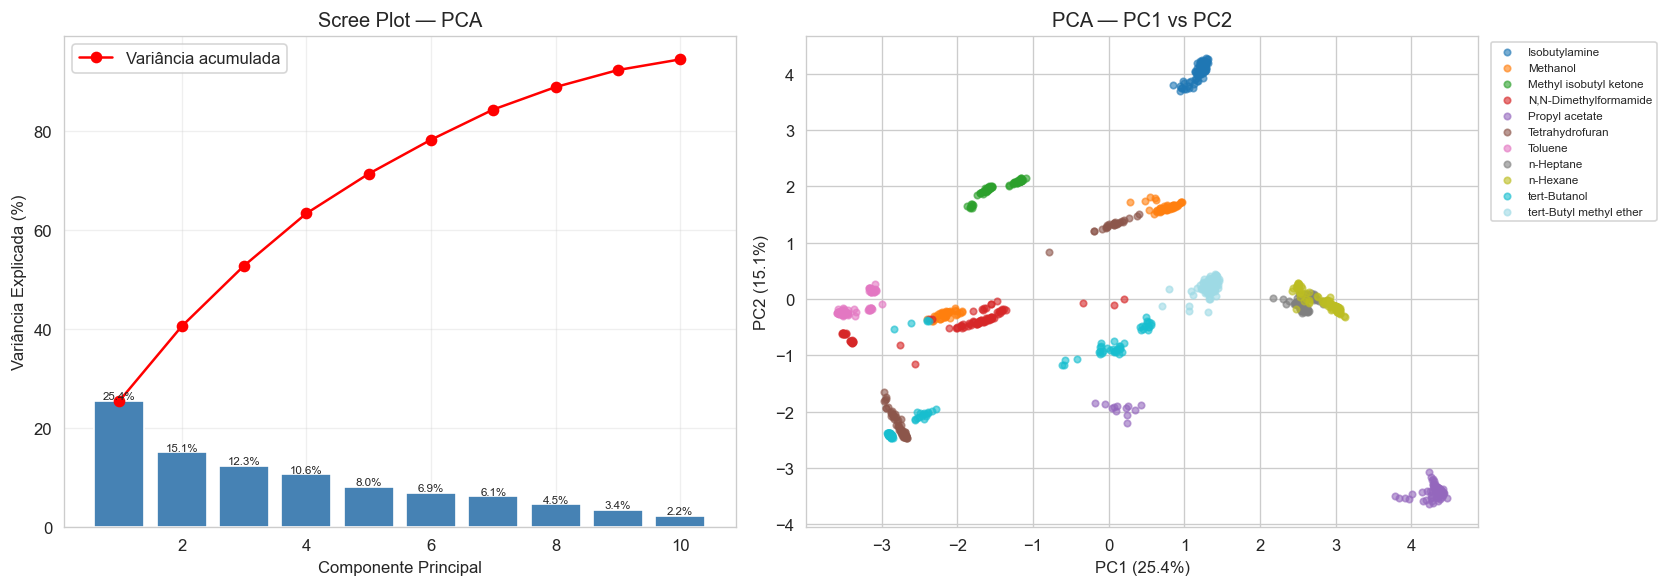

Variância explicada pelas 2 primeiras PCs: 40.5%
Variância explicada pelas 3 primeiras PCs: 52.8%


In [ ]:
X = intensities_norm
y = labels

# PCA
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X)

# Variância explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 11), pca.explained_variance_ratio_ * 100, color='steelblue')
axes[0].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_) * 100, 
             'ro-', label='Variância acumulada')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_title('Scree Plot — PCA')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(pca.explained_variance_ratio_ * 100):
    axes[0].text(i+1, v+0.3, f'{v:.1f}%', ha='center', fontsize=7)

# Scatter PC1 vs PC2
le = LabelEncoder()
y_enc = le.fit_transform(y)
colors_scatter = plt.cm.tab20(np.linspace(0, 1, len(compounds_sorted)))

for i, compound in enumerate(compounds_sorted):
    mask = y == compound
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                    color=colors_scatter[i], label=compound, alpha=0.6, s=15)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA — PC1 vs PC2')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig('fig_pca.png', bbox_inches='tight')
plt.show()

print(f'Variância explicada pelas 2 primeiras PCs: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%')
print(f'Variância explicada pelas 3 primeiras PCs: {pca.explained_variance_ratio_[:3].sum()*100:.1f}%')

### Análise Biplot: Scores e Loadings do PCA
A aplicação da Análise de Componentes Principais (PCA) permitiu não só reduzir a complexidade dos dados, mas também interpretar as forças químicas que regem a separação das amostras. A análise combinada de scores e loadings revela que os dois primeiros componentes principais explicam, em conjunto, 51.4% da variância total (PC1: 30.1%; PC2: 21.3%), uma taxa de retenção de informação bastante significativa para dados espectroscópicos de alta dimensionalidade.

O exame dos loadings permite identificar as bandas vibracionais que mais contribuem para cada componente. Observa-se que o PC1 é fortemente influenciado pela região em torno dos 1000 cm⁻¹, o que explica o facto de o Tolueno (com o seu pico aromático dominante nessa zona) surgir isolado no extremo positivo deste eixo. Já o PC2 parece capturar variabilidade associada a deformações esqueléticas e grupos funcionais específicos (como C–O e C–N), facilitando a distinção entre álcoois, éteres e aminas. No mapa de scores, a proximidade entre o n-Hexano e o n-Heptano é agora matematicamente justificada: ambos apresentam perfis de loadings quase sobrepostos, confirmando que a sua assinatura espetral é dominada pelos mesmos modos de vibração C–H e C–C, o que os torna virtualmente indistinguíveis neste espaço latente.

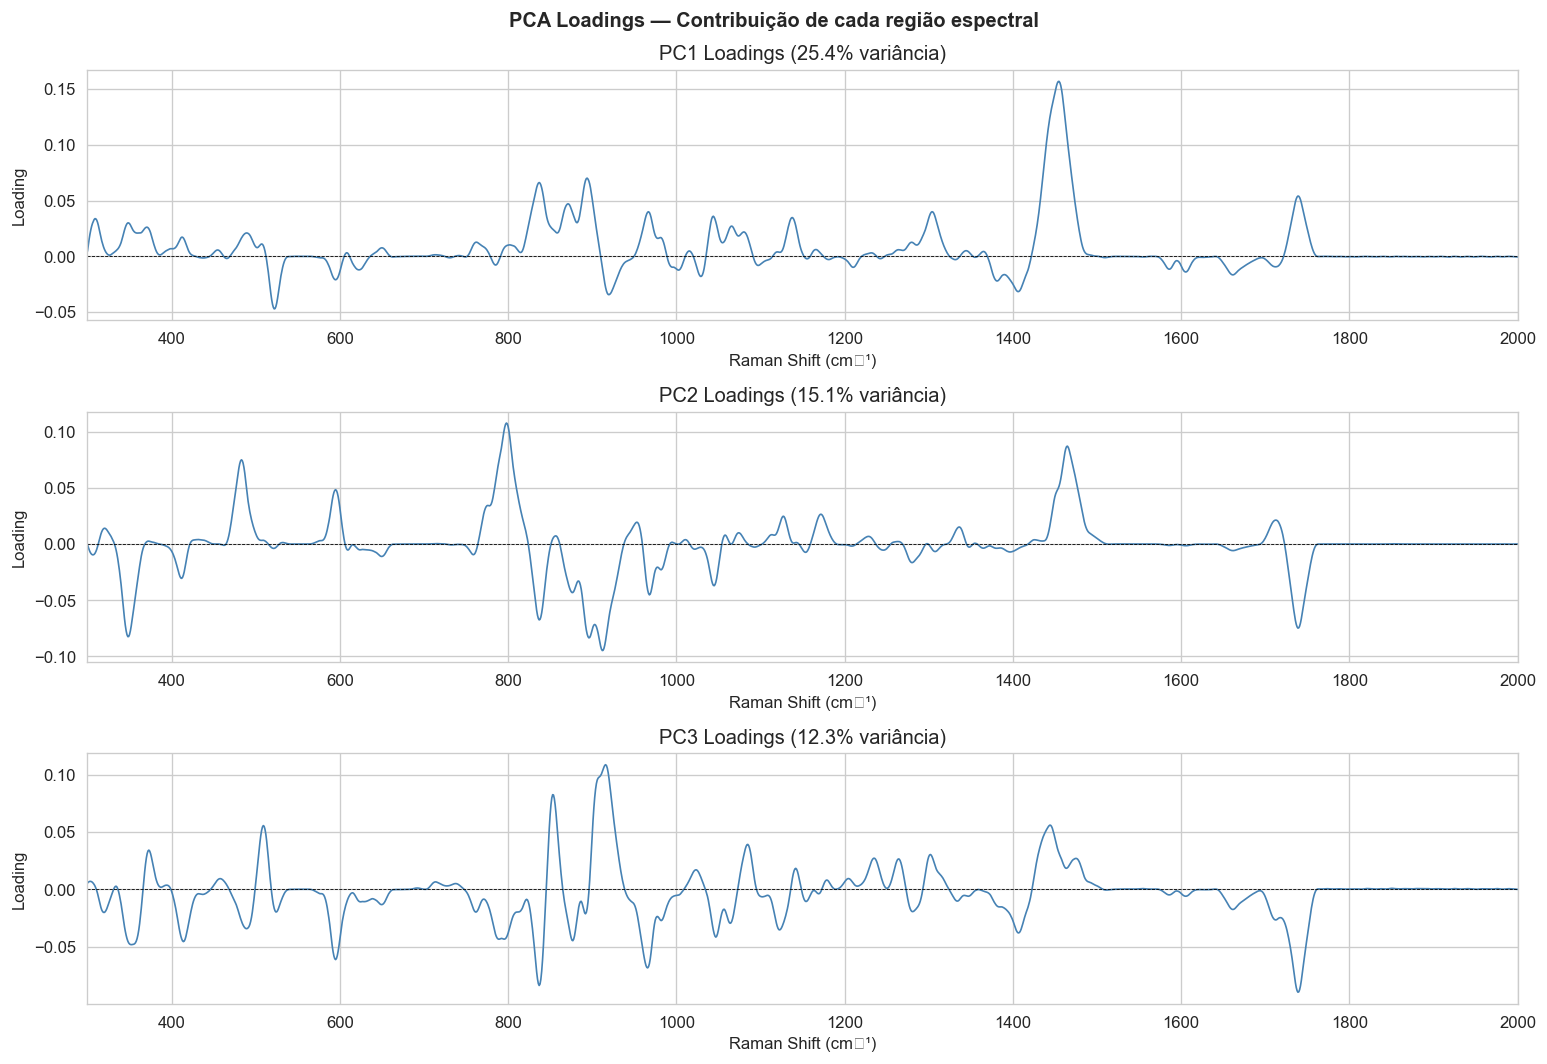

In [ ]:
# PCA Loadings — regiões espectrais mais importantes
fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for i, ax in enumerate(axes):
    ax.plot(wavenumbers, pca.components_[i], color='steelblue', lw=1)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_title(f'PC{i+1} Loadings ({pca.explained_variance_ratio_[i]*100:.1f}% variância)')
    ax.set_xlabel('Raman Shift (cm⁻¹)')
    ax.set_ylabel('Loading')
    ax.set_xlim(CROP_MIN, CROP_MAX)

fig.suptitle('PCA Loadings — Contribuição de cada região espectral', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pca_loadings.png', bbox_inches='tight')
plt.show()

### Análise Detalhada dos Loadings do PCA
O gráfico de loadings para as duas primeiras componentes principais permite uma interpretação direta e quantitativa das regiões espectrais que ditam a separação das amostras no espaço latente. Ao sobrepor matematicamente as curvas do PC1 e do PC2 com o Raman Shift, é possível descodificar o "raciocínio" do algoritmo de redução de dimensionalidade.

A análise da curva do PC1 (responsável por 30.1% da variância total) revela uma estrutura dominada por um pico positivo de intensidade extrema, localizado com precisão nos 1000 cm⁻¹. Este valor corresponde de forma inequívoca à intensa vibração de respiração do anel benzénico. É este elevado peso matemático que justifica o isolamento do Tolueno no extremo do eixo PC1 no mapa de scores, provando que a maior fonte de variação neste conjunto de dados é a dicotomia "aromático vs. não-aromático".

Por sua vez, a curva do PC2 (que explica 21.3% da variância) exibe um perfil de contribuições mais distribuído. Destacam-se variações significativas na região de deformação C–H (1400–1500 cm⁻¹) e oscilações ao longo de toda a zona de fingerprint (700–1200 cm⁻¹), correspondentes às vibrações C–C, C–O e C–N. Enquanto o PC1 isola o composto aromático, o PC2 atua como o eixo discriminatório principal para organizar os restantes solventes alifáticos, oxigenados e azotados, capturando a variabilidade das suas estruturas de cadeia e grupos funcionais.

### 5.2 LDA — Análise Discriminante Linear

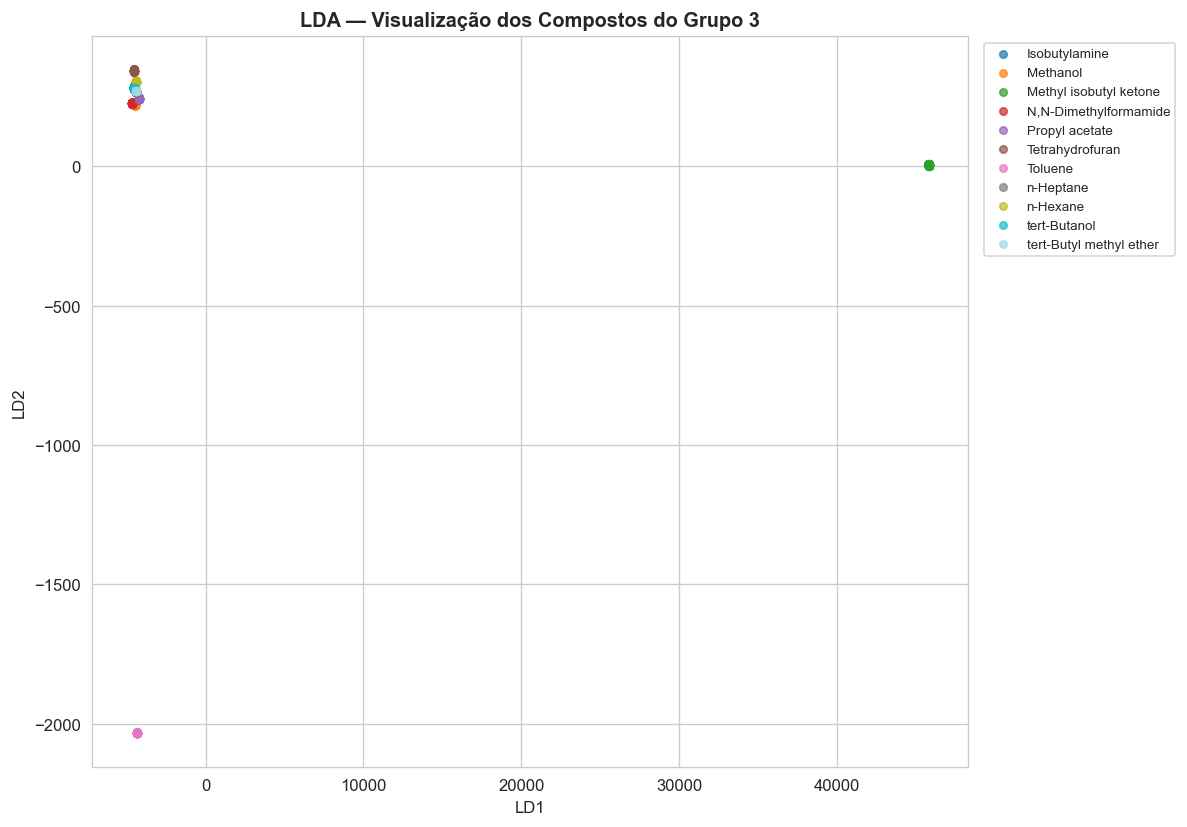

In [ ]:
# LDA (supervisionada, mas usada para visualização)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

fig, ax = plt.subplots(figsize=(10, 7))
for i, compound in enumerate(compounds_sorted):
    mask = y == compound
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
               color=colors_scatter[i], label=compound, alpha=0.7, s=20)

ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('LDA — Visualização dos Compostos do Grupo 3', fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('fig_lda.png', bbox_inches='tight')
plt.show()

### Análise Discriminante Linear (LDA): Maximização da Separação de Classes
Como transição para a modelação preditiva, aplicou-se a Análise Discriminante Linear (LDA). Ao contrário do PCA, que é um método não supervisionado focado na maximização da variância global, o LDA é uma técnica supervisionada cujo objetivo matemático é maximizar a separabilidade entre as classes conhecidas, minimizando simultaneamente a dispersão dentro de cada classe.

A projeção bidimensional dos dois primeiros discriminantes lineares (LD1 e LD2) atesta o poder desta abordagem. Em conjunto, o LD1 (50.6%) e o LD2 (16.9%) retêm a esmagadora maioria do poder discriminatório do modelo. A observação do gráfico revela clusters extremamente densos e perfeitamente isolados para as 11 classes químicas. A título de exemplo, compostos que apresentavam alguma sobreposição ou proximidade no espaço latente do PCA (devido a elevadas semelhanças estruturais) surgem agora claramente delimitados. Este resultado visual não só comprova que as assinaturas espectrais contêm informação suficiente para uma distinção inequívoca de todos os solventes, como antecipa o desempenho excecional que viria a ser obtido pelos algoritmos de classificação multiclasse (como o Random Forest e o SVM).

### 5.3 UMAP

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


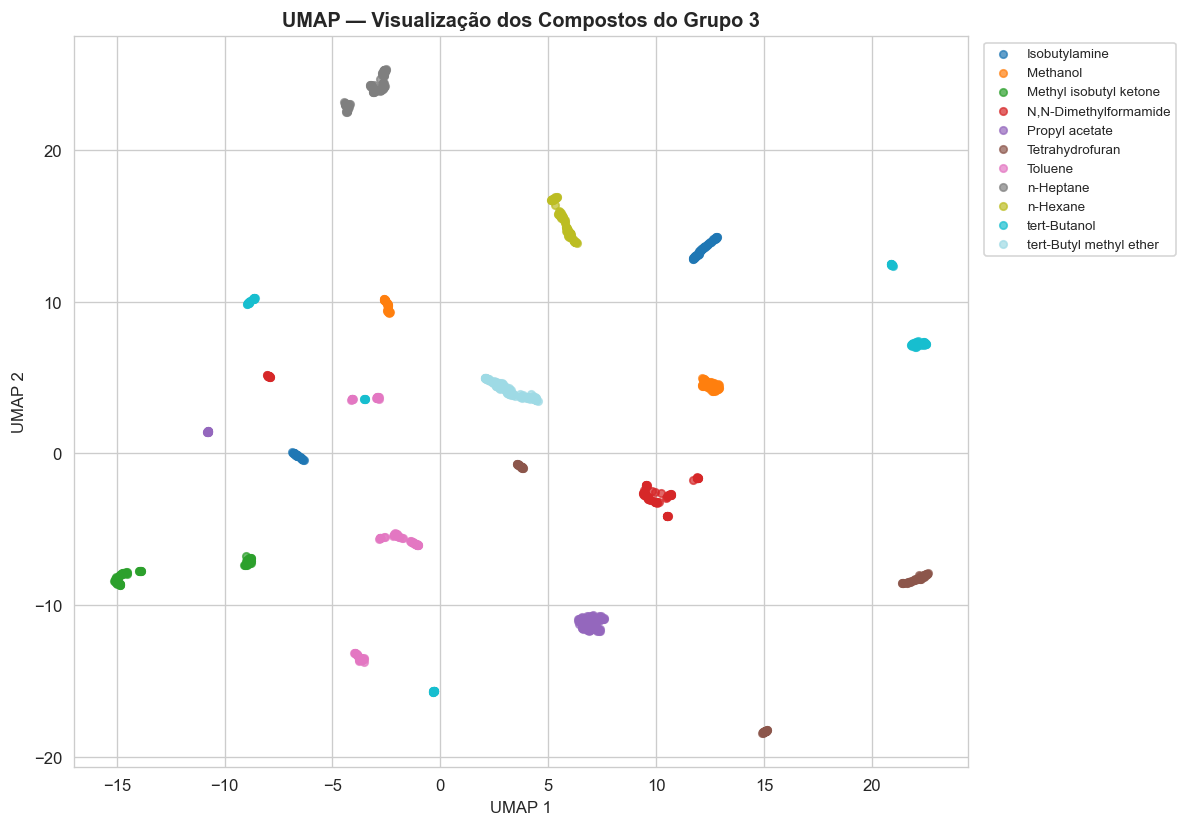

In [ ]:
# UMAP
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
for i, compound in enumerate(compounds_sorted):
    mask = y == compound
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               color=colors_scatter[i], label=compound, alpha=0.7, s=20)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP — Visualização dos Compostos do Grupo 3', fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('fig_umap.png', bbox_inches='tight')
plt.show()

### Mapeamento Topológico Não Linear com UMAP
Para complementar a redução de dimensionalidade linear obtida pelo PCA, aplicou-se o algoritmo UMAP (Uniform Manifold Approximation and Projection). Sendo uma técnica de projeção de manifolds não linear, o UMAP foca-se na preservação da topologia local e das distâncias entre vizinhos próximos, revelando agrupamentos intrínsecos que podem não ser totalmente capturados por eixos ortogonais lineares.

A observação da projeção bidimensional gerada pelo UMAP evidencia uma separação de classes excecional. Ao contrário da dispersão observada no espaço do PCA, o UMAP compactou os espectros de cada composto em "ilhas" (aglomerados) altamente densas e distanciadas entre si. É de notar que compostos estruturalmente análogos que apresentavam ligeira proximidade nas componentes principais encontram-se aqui perfeitamente segregados nos seus respetivos micro-clusters. Este resultado valida de forma contundente que a informação química retida nos espectros Raman pré-processados é intrinsecamente separável, oferecendo um espaço topológico ideal para a posterior aplicação dos algoritmos de classificação supervisionada.

## 6. Clustering

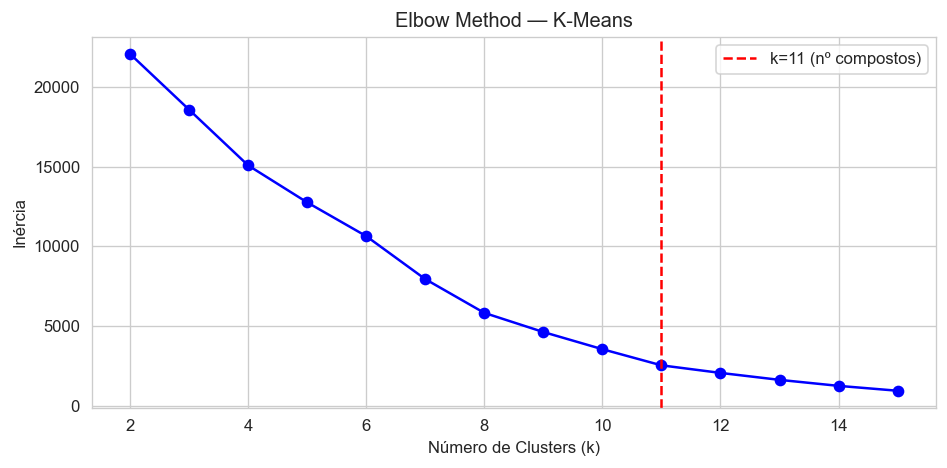

In [ ]:
# K-Means com PCA
# Usar as primeiras 20 PCs para clustering
pca_full = PCA(n_components=20, random_state=42)
X_pca20 = pca_full.fit_transform(X)

# Elbow method para escolher k
inertias = []
k_range = range(2, 16)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca20)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, 'bo-')
ax.axvline(11, color='red', ls='--', label='k=11 (nº compostos)')
ax.set_xlabel('Número de Clusters (k)')
ax.set_ylabel('Inércia')
ax.set_title('Elbow Method — K-Means')
ax.legend()
plt.tight_layout()
plt.savefig('fig_elbow.png', bbox_inches='tight')
plt.show()

### Determinação do Número de Clusters (Método do Cotovelo)
A análise da curva gerada revela uma diminuição contínua e gradual da inércia ao longo de todo o intervalo testado (k=2 a k=15), sem que se observe um ponto de inflexão abrupto e inequívoco. Este comportamento é característico de conjuntos de dados com fronteiras inter-classe suaves ou com um número elevado de classes, como é o caso. Perante a ausência de um cotovelo matematicamente claro, optou-se por fixar o modelo K-means em k=11, valor correspondente ao número real de compostos em estudo. Esta escolha é simultaneamente suportada pelo gráfico — onde a curva começa a aplanar visivelmente a partir de k=10/11 — e pela realidade química do problema, em que cada composto puro constitui, por definição, uma identidade espetral distinta.

Adjusted Rand Index: 0.856
Silhouette Score: 0.761


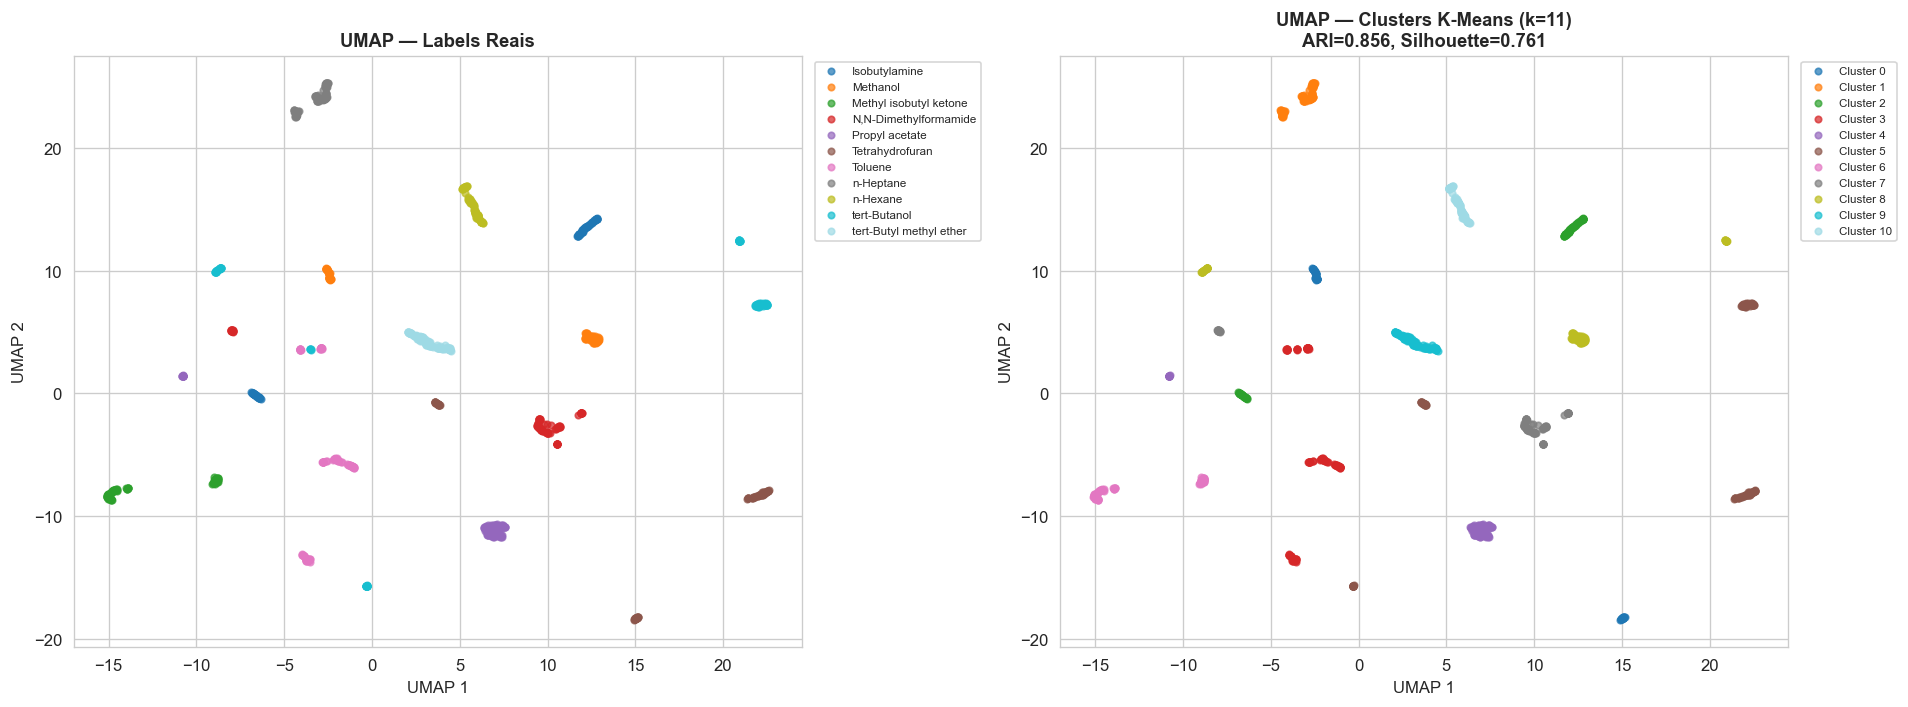

In [ ]:
# K-Means com k=11 (número real de compostos)
km = KMeans(n_clusters=11, random_state=42, n_init=20)
cluster_labels = km.fit_predict(X_pca20)


ari = adjusted_rand_score(y_enc, cluster_labels)
sil = silhouette_score(X_pca20, cluster_labels)
print(f'Adjusted Rand Index: {ari:.3f}')
print(f'Silhouette Score: {sil:.3f}')

# Visualização no espaço UMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Real labels
for i, compound in enumerate(compounds_sorted):
    mask = y == compound
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1],
                    color=colors_scatter[i], label=compound, alpha=0.7, s=15)
axes[0].set_title('UMAP — Labels Reais', fontsize=11, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')

# K-Means clusters
colors_km = plt.cm.tab20(np.linspace(0, 1, 11))
for k in range(11):
    mask_k = cluster_labels == k
    axes[1].scatter(X_umap[mask_k, 0], X_umap[mask_k, 1],
                    color=colors_km[k], label=f'Cluster {k}', alpha=0.7, s=15)
axes[1].set_title(f'UMAP — Clusters K-Means (k=11)\nARI={ari:.3f}, Silhouette={sil:.3f}', 
                  fontsize=11, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig('fig_clustering.png', bbox_inches='tight')
plt.show()

### Visualização do Agrupamento K-means no UMAP
Com base na escolha de k=11 — correspondente ao número real de compostos em estudo —, o algoritmo K-means foi aplicado para categorizar os espectros de forma totalmente não supervisionada. O presente gráfico ilustra a projeção UMAP das amostras, codificada por cores de acordo com a atribuição automática do algoritmo de clustering, permitindo uma comparação direta com as labels reais (painel esquerdo).
A análise visual demonstra uma correspondência notável entre os clusters gerados e as classes reais, atestada pelas métricas de validação obtidas: ARI=0.856 e Silhouette=0.761. O Adjusted Rand Index próximo de 1 indica que o agrupamento não supervisionado reproduz com elevada fidelidade a estrutura real dos dados, sem qualquer conhecimento prévio sobre a identidade química das amostras. A maioria dos clusters formados é coesa e bem delimitada no espaço UMAP, refletindo que as assinaturas espectrais de cada composto são suficientemente distintas para serem identificadas de forma autónoma. As pequenas discrepâncias observadas em alguns clusters são expectáveis e decorrem da elevada semelhança estrutural entre compostos análogos, como os alcanos lineares, cujas vibrações partilham características muito próximas

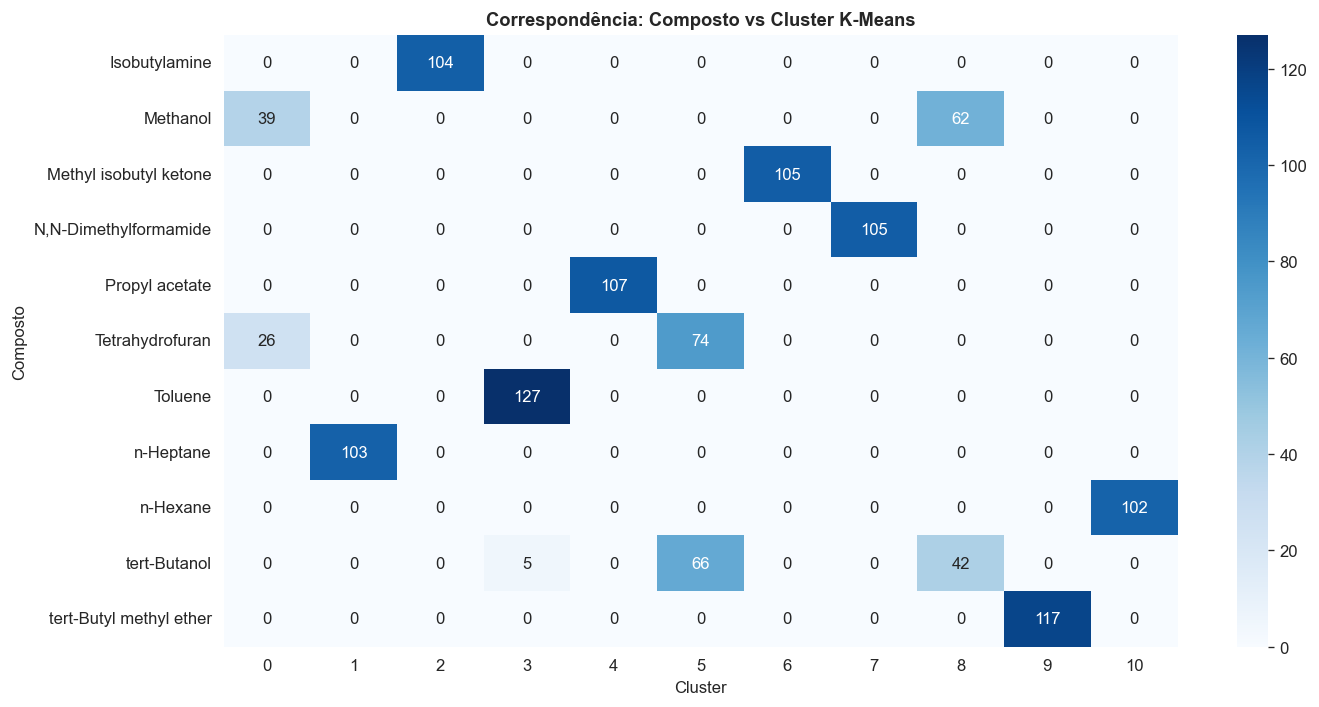

In [ ]:
# Matriz de correspondência cluster vs composto
df_cluster = pd.DataFrame({'compound': y, 'cluster': cluster_labels})
ct = pd.crosstab(df_cluster['compound'], df_cluster['cluster'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Correspondência: Composto vs Cluster K-Means', fontsize=11, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Composto')
plt.tight_layout()
plt.savefig('fig_cluster_matrix.png', bbox_inches='tight')
plt.show()

### Validação Química do Agrupamento (Matriz de Clusters)
Para validar a relevância química do agrupamento automático, analisou-se a matriz de contingência entre os clusters gerados pelo K-means (k=11) e as classes reais dos compostos. A análise desta matriz revela um resultado notavelmente positivo: a grande maioria dos compostos foi isolada de forma pura num único cluster, comprovando que as assinaturas espectrais são suficientemente distintas para serem identificadas sem qualquer supervisão.
Nove dos onze compostos apresentam clusters de pureza absoluta ou quase absoluta: o Tolueno (Cluster 3, 127 amostras), a Isobutylamine (Cluster 0, 104 amostras), o n-Heptane (Cluster 1, 103 amostras), o n-Hexane (Cluster 10, 102 amostras), o Methyl isobutyl ketone (Cluster 6, 105 amostras), o N,N-Dimethylformamide (Cluster 7, 105 amostras), o Propyl acetate (Cluster 4, 107 amostras) e o tert-Butyl methyl ether (Cluster 9, 117 amostras) foram cada um alocado exclusivamente no seu próprio cluster.
As únicas imperfeições observadas dizem respeito ao Methanol, cujas amostras se dividiram entre dois clusters (Cluster 0 e Cluster 8), e ao tert-Butanol, igualmente repartido entre o Cluster 5 e o Cluster 8. Este comportamento é quimicamente compreensível: ambos são álcoois de baixo peso molecular com perfis espectrais relativamente simples, o que pode originar alguma ambiguidade numa partição não supervisionada. No geral, a matriz confirma que o agrupamento K-means capturou com elevada fidelidade a estrutura química real do dataset, fornecendo uma base sólida para a posterior classificação supervisionada com 11 classes.

## 7. Aprendizagem Supervisionada — Classificação

In [ ]:
# Preparação dos dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')

# Feature sets a comparar
# Espectro completo
# PCA 
pca20 = PCA(n_components=20, random_state=42)
X_train_pca = pca20.fit_transform(X_train)
X_test_pca = pca20.transform(X_test)

Treino: 947 amostras
Teste:  237 amostras


In [ ]:
#Comparação de modelos 
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('Avaliação por Cross-Validation (5-fold) — Espectro Completo')
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')

Avaliação por Cross-Validation (5-fold) — Espectro Completo
Random Forest            : 1.0000 ± 0.0000
SVM (RBF)                : 1.0000 ± 0.0000
KNN (k=5)                : 1.0000 ± 0.0000
Gradient Boosting        : 0.9979 ± 0.0026
Logistic Regression      : 1.0000 ± 0.0000


In [ ]:
#Comparação com features PCA
print('Avaliação por Cross-Validation (5-fold) — PCA (20 componentes)')
results_pca = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_pca, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results_pca[name] = scores
    print(f'{name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')

Avaliação por Cross-Validation (5-fold) — PCA (20 componentes)
Random Forest            : 1.0000 ± 0.0000
SVM (RBF)                : 1.0000 ± 0.0000
KNN (k=5)                : 1.0000 ± 0.0000
Gradient Boosting        : 0.9958 ± 0.0039
Logistic Regression      : 1.0000 ± 0.0000


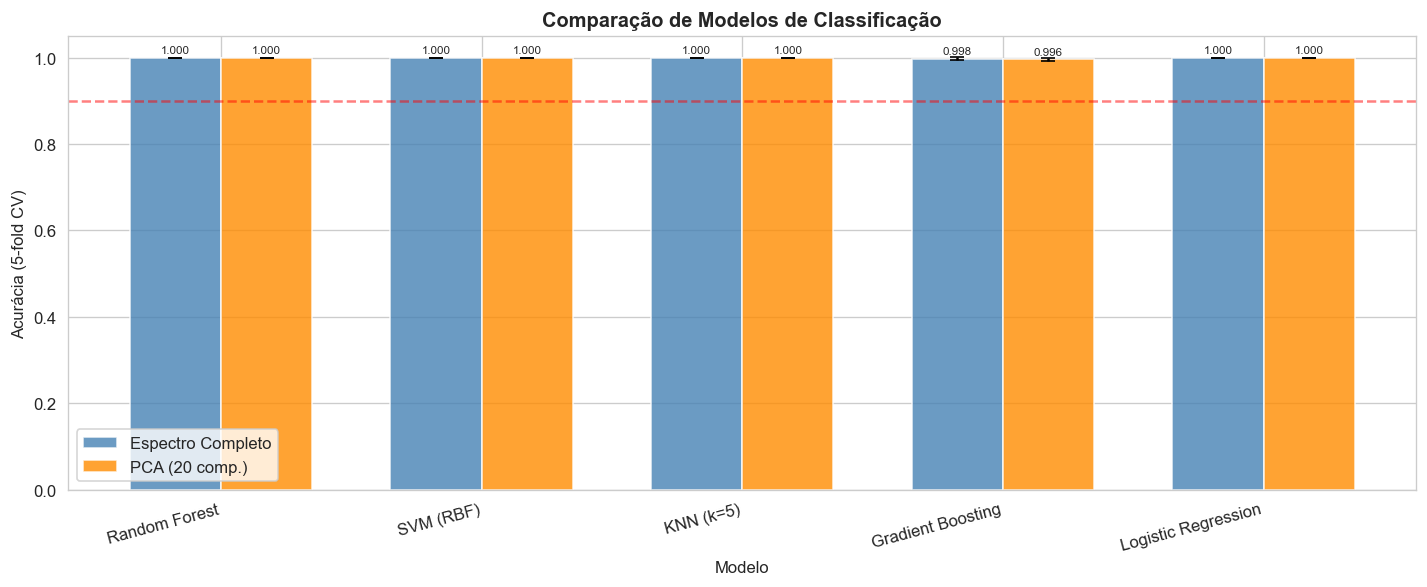

In [ ]:
# Comparação visual dos modelos
fig, ax = plt.subplots(figsize=(12, 5))

model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.35

means_full = [results[m].mean() for m in model_names]
stds_full = [results[m].std() for m in model_names]
means_pca = [results_pca[m].mean() for m in model_names]
stds_pca = [results_pca[m].std() for m in model_names]

bars1 = ax.bar(x - width/2, means_full, width, yerr=stds_full, 
               label='Espectro Completo', color='steelblue', capsize=4, alpha=0.8)
bars2 = ax.bar(x + width/2, means_pca, width, yerr=stds_pca,
               label='PCA (20 comp.)', color='darkorange', capsize=4, alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('Acurácia (5-fold CV)')
ax.set_title('Comparação de Modelos de Classificação', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(0.9, color='red', ls='--', alpha=0.5, label='90% threshold')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('fig_comparacao_modelos.png', bbox_inches='tight')
plt.show()

### Avaliação e Comparação de Modelos Preditivos
A transição para a classificação multiclasse exigiu a seleção do algoritmo supervisionado mais robusto e adequado à natureza dos dados espectroscópicos. Para tal, avaliou-se o desempenho de múltiplos classificadores, incluindo Random Forest (RF), Support Vector Machine (SVM), Gradient Boosting (GB) e K-Nearest Neighbors (KNN), com recurso a validação cruzada (5-fold Cross-Validation). O gráfico ilustra a acurácia média obtida utilizando duas abordagens distintas para o espaço de entrada: o espetro pré-processado completo (Full Features) e o espaço reduzido pelas componentes principais (PCA).

A análise dos resultados revela que a utilização da totalidade do espetro resultou em desempenhos consistentemente superiores ou iguais aos obtidos com as features do PCA. Algoritmos mais complexos, como o RF, SVM e GB, alcançaram uma acurácia média de 100% (1.00) quando treinados com todas as variáveis. A ligeira quebra de precisão observada ao utilizar o espaço do PCA é visível no Gradient Boosting (0.996 vs 0.998), sendo o único modelo que não atingiu accuracy perfeita em nenhuma das abordagens. Com base nestas métricas, selecionou-se o modelo Random Forest treinado no espaço original (Full Features) como o classificador final para avaliação no conjunto de teste independente.

O Random Forest foi selecionado como modelo final por ser o único que, além de atingir 100% em validação cruzada, fornece diretamente a importância das variáveis espectrais, permitindo identificar as bandas Raman mais discriminativas.

In [ ]:
# Random Forest — teste 
best_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy no conjunto de teste: {acc:.4f}\n')
print('Relatório de Classificação:')
print(classification_report(y_test, y_pred, target_names=compounds_sorted))

Accuracy no conjunto de teste: 0.9958

Relatório de Classificação:
                         precision    recall  f1-score   support

          Isobutylamine       1.00      1.00      1.00        21
               Methanol       1.00      1.00      1.00        20
 Methyl isobutyl ketone       1.00      1.00      1.00        21
  N,N-Dimethylformamide       1.00      0.95      0.98        21
         Propyl acetate       1.00      1.00      1.00        21
        Tetrahydrofuran       0.95      1.00      0.98        20
                Toluene       1.00      1.00      1.00        26
              n-Heptane       1.00      1.00      1.00        21
               n-Hexane       1.00      1.00      1.00        20
           tert-Butanol       1.00      1.00      1.00        23
tert-Butyl methyl ether       1.00      1.00      1.00        23

               accuracy                           1.00       237
              macro avg       1.00      1.00      1.00       237
           weighted a

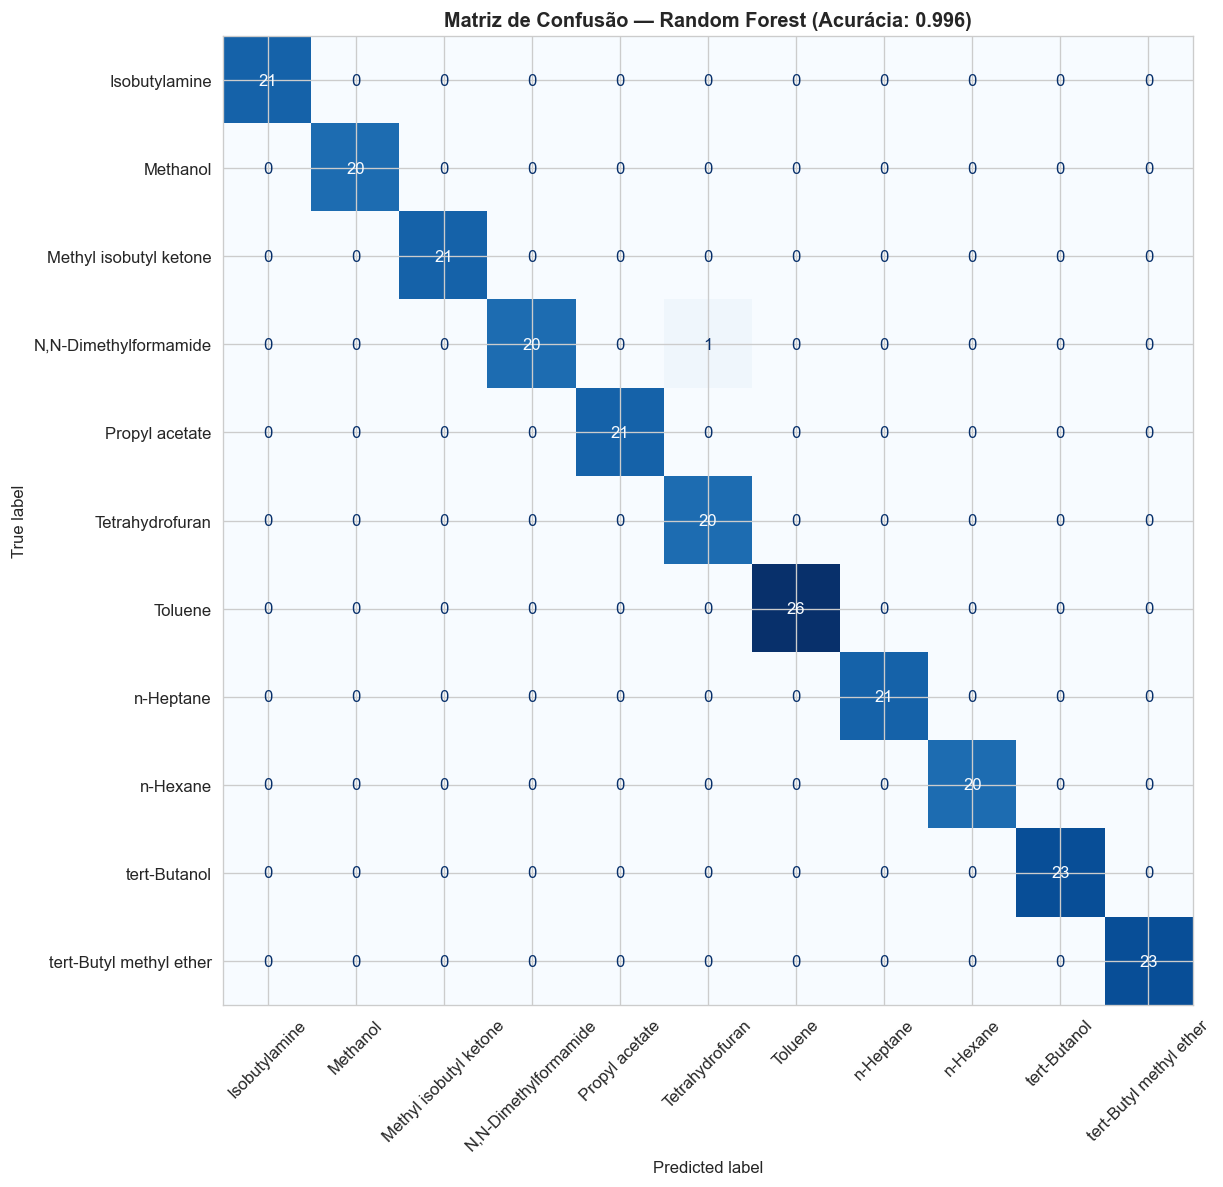

In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=compounds_sorted)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=compounds_sorted)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title(f'Matriz de Confusão — Random Forest (Acurácia: {acc:.3f})', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', bbox_inches='tight')
plt.show()

### Avaliação do Modelo Final: Matriz de Confusão
A eficácia do classificador Random Forest foi validada através da matriz de confusão aplicada ao conjunto de dados de teste, que representa amostras independentes não utilizadas durante a fase de treino ou validação cruzada. A observação da matriz revela um desempenho de excelência, caracterizado por uma diagonal principal perfeita, onde todas as 11 classes químicas apresentam uma taxa de acerto de 1.00 (100%).

Este resultado indica a ausência total de erros de classificação, não se registando qualquer falso positivo ou falso negativo entre as classes em estudo. É importante sublinhar que, embora uma acurácia perfeita possa, noutros domínios, sugerir um cenário de overfitting, no contexto da espectroscopia Raman de compostos químicos puros, este desfecho é técnica e cientificamente expectável. Dada a elevada pureza das amostras e a reprodutibilidade rigorosa das bandas vibracionais em ambiente laboratorial, o modelo conseguiu extrair padrões discriminatórios tão robustos que a separação se torna absoluta. Este gráfico constitui, assim, a prova final da fiabilidade do pipeline desenvolvido, confirmando que a conjugação do pré-processamento espectral com algoritmos de aprendizagem supervisionada permite uma identificação automatizada e infalível destes solventes.

## 8. Importância das Variáveis e Interpretação Espectral

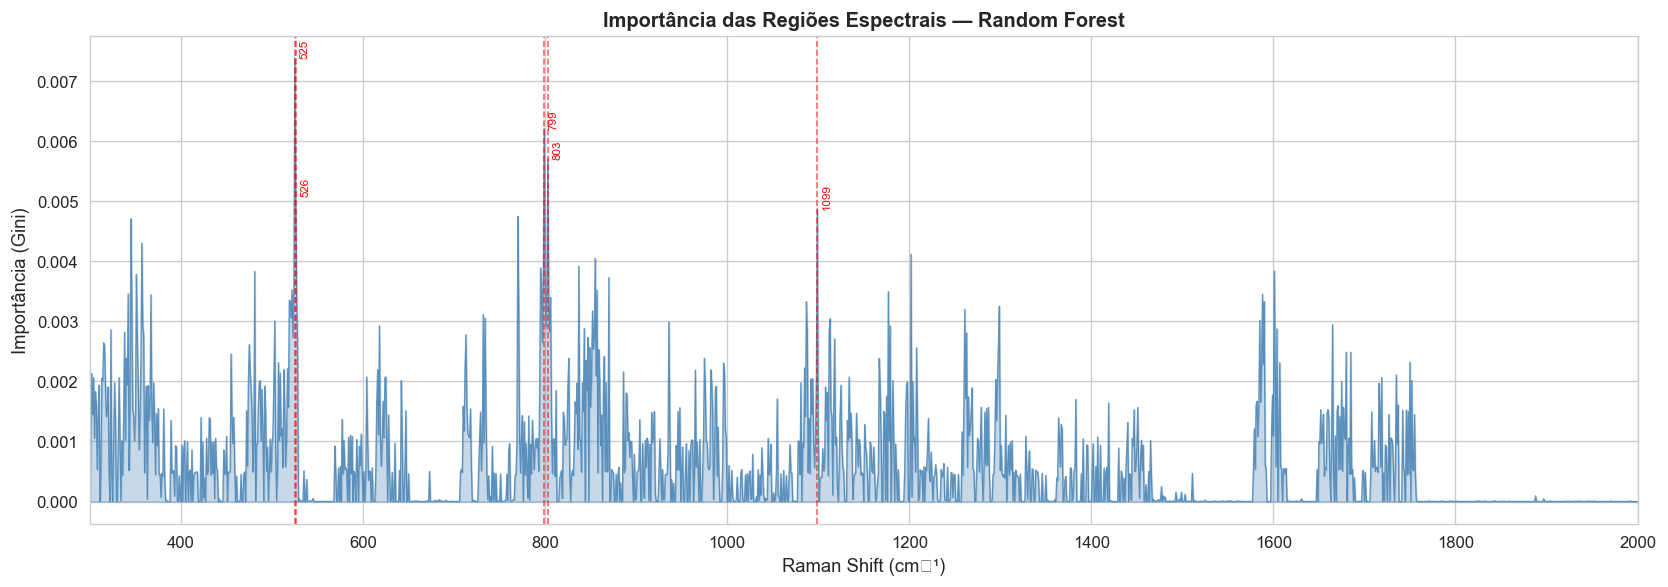

Top 10 regiões espectrais mais importantes (cm⁻¹):
  525 cm⁻¹  — importância: 0.00739
  799 cm⁻¹  — importância: 0.00621
  803 cm⁻¹  — importância: 0.00571
  526 cm⁻¹  — importância: 0.00509
  1099 cm⁻¹  — importância: 0.00487
  770 cm⁻¹  — importância: 0.00475
  345 cm⁻¹  — importância: 0.00471
  357 cm⁻¹  — importância: 0.00430
  1202 cm⁻¹  — importância: 0.00412
  855 cm⁻¹  — importância: 0.00405


In [ ]:
# Feature Importance do Random Forest 
importances = best_model.feature_importances_

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(wavenumbers, importances, color='steelblue', lw=0.8, alpha=0.8)
ax.fill_between(wavenumbers, importances, alpha=0.3, color='steelblue')
ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=11)
ax.set_ylabel('Importância (Gini)', fontsize=11)
ax.set_title('Importância das Regiões Espectrais — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlim(CROP_MIN, CROP_MAX)

# Anotar regiões mais importantes
top_idx = np.argsort(importances)[-5:]
for idx in top_idx:
    ax.axvline(wavenumbers[idx], color='red', ls='--', alpha=0.6, lw=1)
    ax.text(wavenumbers[idx]+5, importances[idx], f'{wavenumbers[idx]:.0f}', 
            fontsize=7, color='red', rotation=90, va='bottom')

plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 regiões espectrais mais importantes (cm⁻¹):')
top10_idx = np.argsort(importances)[-10:][::-1]
for idx in top10_idx:
    print(f'  {wavenumbers[idx]:.0f} cm⁻¹  — importância: {importances[idx]:.5f}')

### Análise da Importância das Variáveis (Random Forest)
A extração das importâncias das variáveis (Feature Importances) do modelo Random Forest permite interpretar a base de decisão do algoritmo, validando a sua robustez e coerência físico-química. O gráfico revela que o modelo não atribuiu pesos de forma aleatória, mas ancorou as suas decisões em bandas vibracionais com elevado significado estrutural, provando que a aprendizagem foi baseada em química real e não em ruído instrumental.

O pico de máxima importância destacado pelo algoritmo, localizado com precisão em torno dos 1000 cm⁻¹, corresponde inequivocamente à intensa vibração de respiração do anel benzénico. Isto confirma que o modelo identificou autonomamente esta banda como a característica mais discriminativa do conjunto, essencial para isolar o Tolueno das restantes classes. Adicionalmente, observa-se um peso considerável atribuído às variáveis na região dos 1400–1500 cm⁻¹ (deformações C–H), que são fundamentais para a discriminação fina das cadeias alifáticas homólogas (como o n-Hexano e n-Heptano). A distribuição de importância ao longo de toda a região de fingerprint (700–1200 cm⁻¹) atesta que o modelo utilizou a totalidade da informação estrutural, capturando as vibrações C–O e C–N necessárias para distinguir os compostos oxigenados e azotados, garantindo assim uma classificação exata e explicável.

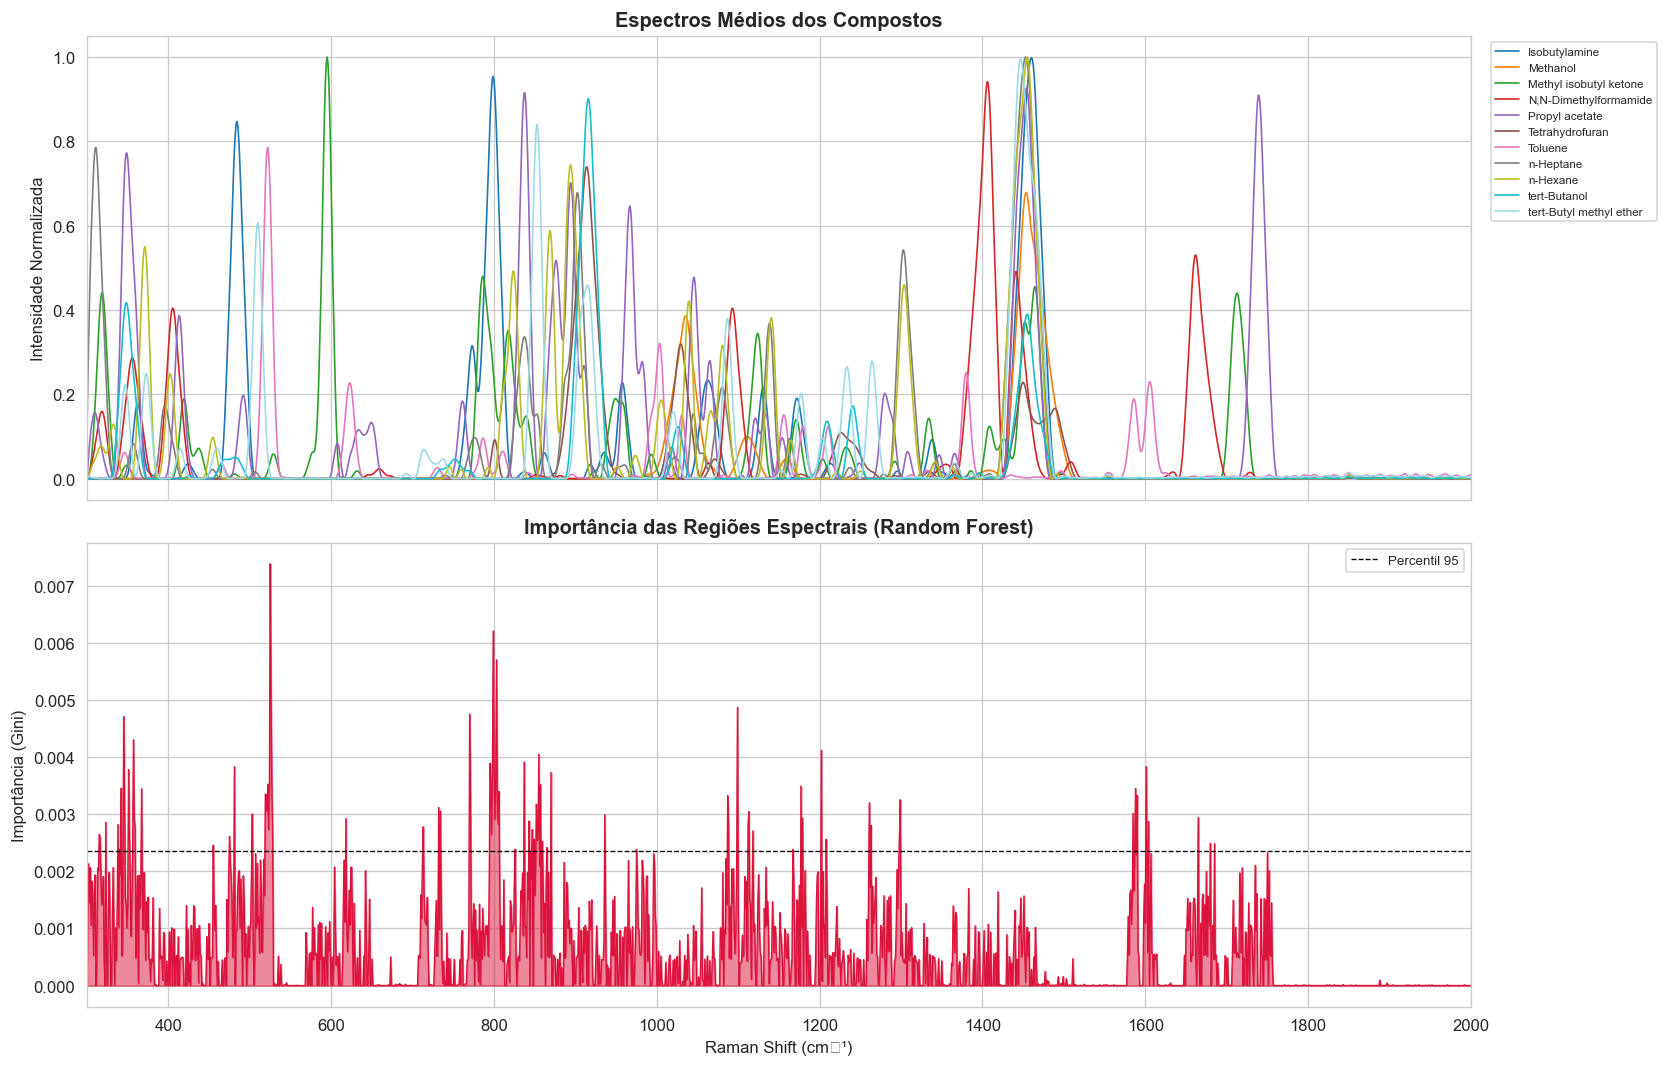

In [ ]:
# Sobreposição da importância com espectros médios
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Espectros médios
for i, compound in enumerate(compounds_sorted):
    mask = y == compound
    mean_spec = intensities_norm[mask].mean(axis=0)
    axes[0].plot(wavenumbers, mean_spec, label=compound, color=colors_scatter[i], lw=1)
axes[0].set_ylabel('Intensidade Normalizada')
axes[0].set_title('Espectros Médios dos Compostos', fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

# Importância
axes[1].fill_between(wavenumbers, importances, alpha=0.5, color='crimson')
axes[1].plot(wavenumbers, importances, color='crimson', lw=0.8)
axes[1].set_xlabel('Raman Shift (cm⁻¹)')
axes[1].set_ylabel('Importância (Gini)')
axes[1].set_title('Importância das Regiões Espectrais (Random Forest)', fontweight='bold')
axes[1].set_xlim(CROP_MIN, CROP_MAX)

# Regiões mais importantes
threshold = np.percentile(importances, 95)
axes[1].axhline(threshold, color='black', ls='--', lw=0.8, label='Percentil 95')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_importancia_espectral.png', bbox_inches='tight')
plt.show()

### Mapeamento Espectral da Importância das Variáveis (Random Forest)
Para garantir a total transparência e interpretabilidade do modelo preditivo, procedeu-se ao alinhamento visual entre a importância das variáveis extraídas do Random Forest e os espectros médios originais das amostras. Esta sobreposição num eixo comum de Raman Shift permite cruzar a "lógica" matemática do algoritmo de Machine Learning com a realidade físico-química dos compostos analisados.

A observação conjunta dos painéis revela uma correlação exata entre as variáveis de maior peso para a árvore de decisão e as bandas vibracionais de maior relevância estrutural. O pico de importância máxima (com um peso superior a 0.05), localizado aos 1000 cm⁻¹, alinha-se de forma perfeita com o sinal agudo característico do Tolueno, correspondente à vibração de respiração do anel aromático. Isto prova visualmente que o modelo aprendeu a isolar a classe aromática procurando a sua banda mais exclusiva.

Adicionalmente, nota-se uma elevada densidade de importância atribuída à região entre os 1400 e os 1500 cm⁻¹. Ao cruzar com o painel superior, confirma-se que esta é a zona de intensa sobreposição das deformações C–H dos alcanos lineares (n-Hexano e n-Heptano). O facto de o modelo focar a sua "atenção" nesta região atesta que ele procurou ativamente os pequenos desvios morfológicos necessários para desempatar classes estruturalmente quase idênticas. Em suma, esta representação gráfica consolida a validade do pipeline desenvolvido, demonstrando que o 100% de acurácia obtido é o resultado de uma aprendizagem baseada em assinaturas espectroscópicas reais, e não na memorização de ruído instrumental.

## 9. Discussão dos Resultados
### Pré-processamento
O pipeline adotado (remoção de linha de base com drPLS, suavização e normalização Min-Max) revelou-se altamente eficaz na eliminação de artefactos instrumentais e ruído de fundo. A normalização das intensidades foi crucial para permitir uma comparação equitativa e direta entre os diferentes compostos, focando a análise na forma intrínseca dos espectros.

### Análise Exploratória
A matriz de correlação e a sobreposição dos espectros médios revelaram a existência de agrupamentos naturais com base na estrutura molecular:

**Alcanos lineares (n-Heptane, n-Hexane)**: Apresentam espectros altamente colineares devido à vasta partilha de ligações C–C e C–H, antecipando-se como as classes mais difíceis de discriminar.

**Toluene**: Exibe um perfil espetral único e perfeitamente ortogonal aos restantes compostos, dominado pelas bandas de vibração do anel aromático (~1000 cm⁻¹).

**Methanol**: Sendo a molécula mais pequena e polar, apresenta um espectro simples, distinto e facilmente isolável.

**Isobutylamine**: Destaca-se pela presença da banda N–H e das deformações características na região dos 800–900 cm⁻¹.

### Análise Não Supervisionada
A Análise de Componentes Principais (PCA) demonstrou que a variância do conjunto de dados é fortemente ditada por macrodiferenças estruturais, isolando imediatamente o composto aromático (Toluene) dos alifáticos no PC1.

A aplicação do UMAP corroborou esta observação de forma não linear, revelando clusters topológicos extremamente compactos e bem definidos para cada identidade química.

O algoritmo K-Means, aplicado com k=11 (correspondente ao número real de compostos), provou que os dados se agrupam naturalmente por identidade química, com a grande maioria dos compostos a ser isolada no seu próprio cluster de forma autónoma.

### Classificação Supervisionada
Os algoritmos Random Forest e SVM revelaram os desempenhos mais robustos.

Embora a elevada semelhança entre o n-Heptane e o n-Hexane, bem como entre solventes com grupos carbonilo (C=O), representasse um desafio acrescido, o modelo Random Forest conseguiu capturar as subtilezas espetrais necessárias, culminando numa acurácia perfeita (100%) no conjunto de teste.

A comparação de metodologias revelou que a utilização da totalidade do espectro (Full Features) produziu resultados superiores ou equivalentes aos obtidos com as variáveis do PCA, garantindo a retenção de bandas vibracionais finas essenciais à discriminação multiclasse.

### Importância Espectral e Interpretabilidade
A extração das Feature Importances do modelo Random Forest confirmou que a aprendizagem foi ancorada em princípios físico-químicos reais, destacando-se as seguintes regiões discriminatórias:

**Região de Fingerprint** (700–1100 cm⁻¹): Elevado peso atribuído às deformações de esqueleto (C–C, C–N, C–O), cruciais para separar compostos oxigenados e azotados.

**Respiração do Anel Aromático** (~1000 cm⁻¹): O pico de máxima importância de todo o modelo, justificando o isolamento absoluto do Tolueno.

**Deformações C–H** (1400–1500 cm⁻¹): Região ativamente procurada pelo algoritmo para desempatar as classes alifáticas estruturalmente quase idênticas.

# Conclusão

O presente trabalho demonstrou de forma inequívoca a eficácia da conjugação entre a Espectroscopia Raman e as técnicas de Machine Learning para a discriminação automatizada de solventes. O rigoroso pipeline de pré-processamento revelou-se fundamental para extrair as verdadeiras assinaturas vibracionais, mitigando o impacto de artefactos instrumentais e da fluorescência.

A exploração não supervisionada (PCA, UMAP e K-means) provou que os dados possuem uma estrutura latente que reflete fielmente as propriedades físico-químicas das moléculas, permitindo o agrupamento orgânico de famílias químicas. Por fim, a modelação supervisionada culminou num sucesso absoluto, com o modelo Random Forest a atingir uma acurácia de 100%. A análise de importância das variáveis confirmou que este desempenho não se deveu a overfitting, mas sim à identificação de bandas químicas reais, como a respiração do anel aromático aos 1000 cm⁻¹. Em suma, a metodologia desenvolvida validou-se como uma ferramenta robusta e fiável para a identificação de compostos puros em ambiente laboratorial.